<a href="https://colab.research.google.com/github/nurularliana/Luxury-Loan-Analysis/blob/main/DEEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Preparation

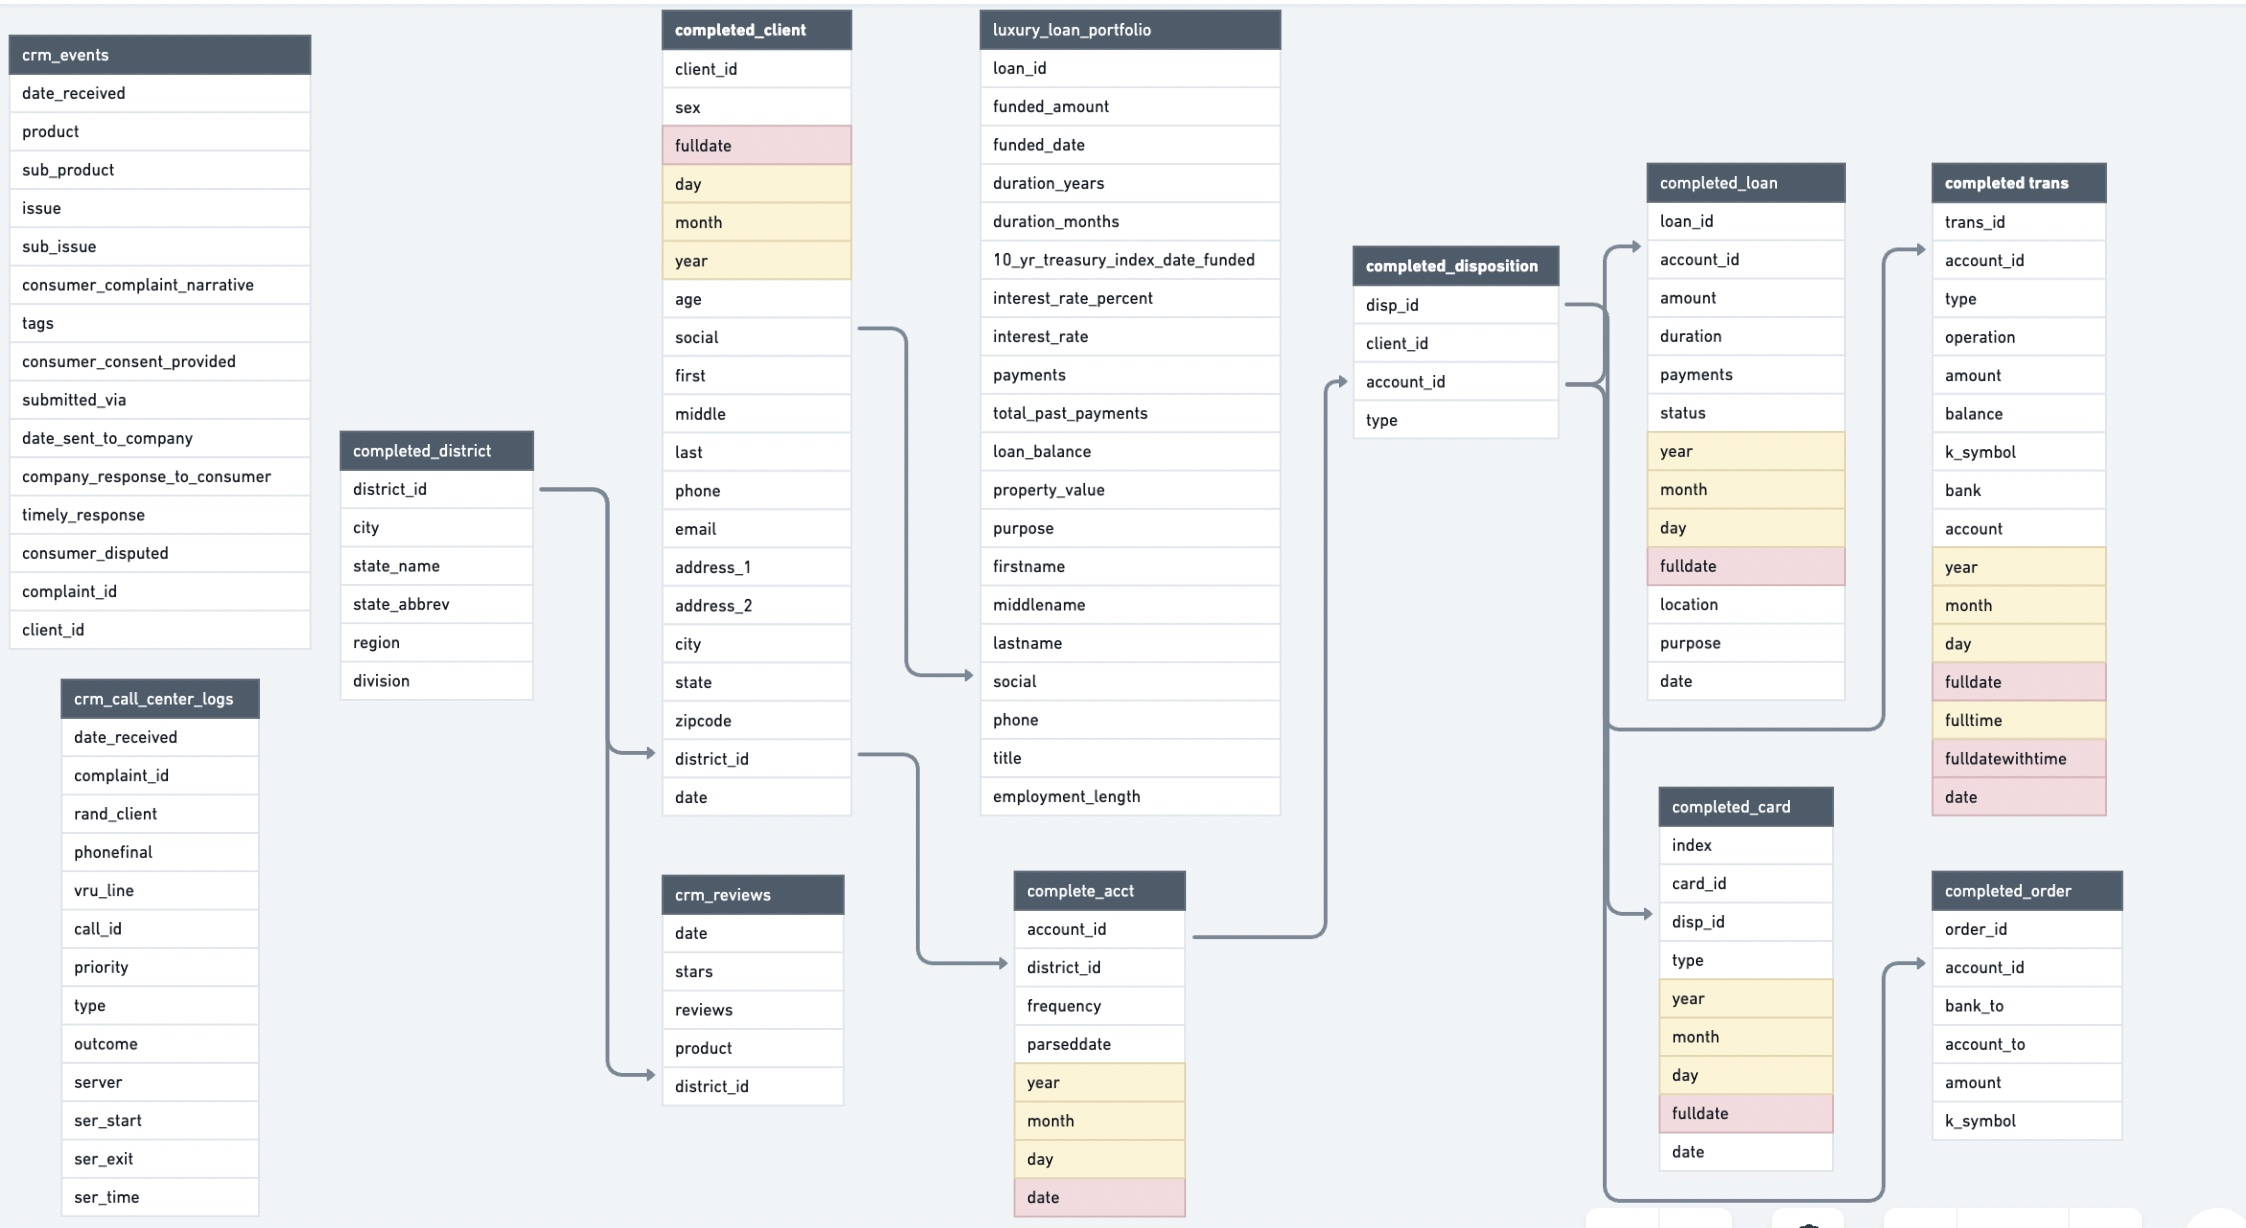

In [ ]:
import gdown
import shutil
import pandas as pd                 # Library used for working with data sets and perform data analysis.
import numpy as np                  # To perform mathematical operasion and statistics
from datetime import datetime       # Used to perform dates and time manipulation
import seaborn as sns               # To perform data visualization
import matplotlib.pyplot as plt     # To perform data visualization
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split  # For splitting the dataset into training and testing sets
from sklearn.linear_model import LogisticRegression  # For implementing logistic regression for classification tasks
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # For evaluating model performance using accuracy, confusion matrix, and detailed classification metrics

# Linear regression (statistical approach)
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kabure/retail-bankingdemodata")

print("Path to dataset files:", path)

100%|██████████| 31.8M/31.8M [00:02<00:00, 16.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kabure/retail-bankingdemodata/versions/1


In [ ]:
import os
# List all files in the downloaded folder
for file in os.listdir(path):
    print(file)

crm_reviews.csv
crm_call_center_logs.csv
luxuryloanportfolio.csv
completedloan.csv
completedtrans.csv
completedclient.csv
crm_events.csv
completedorder.csv
completeddisposition.csv
completedacct.csv
completedcard.csv
completeddistrict.csv


##Load All Dataframe

###District

In [ ]:
# Read the completeddistrict.csv file into a DataFrame
df_completed_district = pd.read_csv(os.path.join(path, "completeddistrict.csv"))

# Display the first few rows of the DataFrame
df_completed_district.head()

,district_id,city,state_name,state_abbrev,region,division
0,1,New York City,New York,NY,Northeast,Middle Atlantic
1,2,Jacksonville,Florida,FL,South,South Atlantic
2,3,Columbus,Ohio,OH,Midwest,East North Central
3,4,Charlotte,North Carolina,NC,South,South Atlantic
4,5,Indianapolis,Indiana,IN,Northeast,East North Central


###Disposition

In [ ]:
# Read the completeddisposition.csv file into a DataFrame
df_completed_disposition = pd.read_csv(os.path.join(path, "completeddisposition.csv"))

# Display the first few rows of the DataFrame
df_completed_disposition

,disp_id,client_id,account_id,type
0,D00000001,1,A00000001,Owner
1,D00000002,2,A00000002,Owner
2,D00000003,3,A00000002,User
3,D00000004,4,A00000003,Owner
4,D00000005,5,A00000003,User
...,...,...,...,...
5364,D00013647,13955,A00011349,Owner
5365,D00013648,13956,A00011349,User
5366,D00013660,13968,A00011359,Owner
5367,D00013663,13971,A00011362,Owner


In [ ]:
# Change 'client_id' format to 'C' followed by an 8-digit number
df_completed_disposition['client_id_new'] = df_completed_disposition['client_id'].apply(lambda x: 'C' + str(x).zfill(8))

# Display the first few rows of the 'client_id' column to verify the change
df_completed_disposition[['client_id_new']]

,client_id_new
0,C00000001
1,C00000002
2,C00000003
3,C00000004
4,C00000005
...,...
5364,C00013955
5365,C00013956
5366,C00013968
5367,C00013971


###Card

In [ ]:
# Read the completedcard.csv file into a DataFrame
df_completed_card = pd.read_csv(os.path.join(path, "completedcard.csv"))

# Display the first few rows of the DataFrame
df_completed_card

,card_id,disp_id,type,year,month,day,fulldate,date
0,V00001005,D00009285,VISA Signature,2013,11,7,2013-11-07,2013-11-07
1,V00000104,D00000588,VISA Signature,2014,1,19,2014-01-19,2014-01-19
2,V00000747,D00004915,VISA Signature,2014,2,5,2014-02-05,2014-02-05
3,V00000070,D00000439,VISA Signature,2014,2,8,2014-02-08,2014-02-08
4,V00000577,D00003687,VISA Signature,2014,2,15,2014-02-15,2014-02-15
...,...,...,...,...,...,...,...,...
887,V00000125,D00000694,VISA Infinite,2018,12,26,2018-12-26,2018-12-26
888,V00000674,D00004360,VISA Signature,2018,12,28,2018-12-28,2018-12-28
889,V00000322,D00002063,VISA Signature,2018,12,28,2018-12-28,2018-12-28
890,V00000685,D00004467,VISA Signature,2018,12,29,2018-12-29,2018-12-29


###Complete Client

In [ ]:
# Read the completeddistrict.csv file into a DataFrame
df_completed_client_og = pd.read_csv(os.path.join(path, "completedclient.csv"))

# Make a copy of the original data for data cleaning
df_completed_client = df_completed_client_og.copy()

# Display the first few rows of the DataFrame
df_completed_client

,client_id,sex,fulldate,day,month,year,age,social,first,middle,last,phone,email,address_1,address_2,city,state,zipcode,district_id,date
0,C00000001,Female,1990-12-13,13,12,1990,29,926-93-2157,Emma,Avaya,Smith,367-171-6840,emma.smith@gmail.com,387 Wellington Ave.,Unit 1,Albuquerque,NM,47246,18,1990-12-13
1,C00000002,Male,1965-02-04,4,2,1965,54,806-94-5725,Noah,Everest,Thompson,212-423-7734,noah.thompson@gmail.com,75 W. Berkshire St.,NaN,New York City,NY,10040,1,1965-02-04
2,C00000003,Female,1960-10-09,9,10,1960,59,614-70-9100,Olivia,Brooklynne,Johnson,212-425-6932,olivia.johnson@outlook.com,36 Second St.,NaN,New York City,NY,10162,1,1960-10-09
3,C00000004,Male,1976-12-01,1,12,1976,43,580-20-3414,Liam,Irvin,White,951-567-8925,liam.white@gmail.com,7607 Sunnyslope Street,NaN,Indianapolis,IN,49047,5,1976-12-01
4,C00000005,Female,1980-07-03,3,7,1980,39,536-14-5809,Sophia,Danae,Williams,428-265-1568,sophia.williams@gmail.com,755 Galvin Street,NaN,Indianapolis,IN,40852,5,1980-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5364,C00013955,Female,1965-10-30,30,10,1965,54,830-38-3530,Adrianna,Jillian,Moore,212-205-7422,adrianna.moore@outlook.com,9405 SW. Leeton Ridge Drive,NaN,New York City,NY,10121,1,1965-10-30
5365,C00013956,Male,1963-04-06,6,4,1963,56,773-25-4409,Aaron,Roman,Park,212-645-8820,aaron.park@gmail.com,7021 Chapel Ave.,NaN,New York City,NY,10118,1,1963-04-06
5366,C00013968,Male,1988-04-13,13,4,1988,31,227-17-0778,Eli,Leonardo,Warner,508-465-5164,eli.warner@hotmail.com,43 Edgemont Dr.,NaN,Fall River,MA,2721,61,1988-04-13
5367,C00013971,Female,1982-10-19,19,10,1982,37,278-77-3298,Ruth,Joy,Martin,856-636-3840,ruth.martin@gmail.com,7087 E. Pennsylvania Street,Unit 8,Danbury,CT,48475,67,1982-10-19


*Convert Data Type*

In [ ]:
# Convert 'fulldate' and 'date' to datetime
df_completed_client['fulldate'] = pd.to_datetime(df_completed_client['fulldate'])
df_completed_client['date'] = pd.to_datetime(df_completed_client['date'])

# Convert 'zipcode' and 'district_id' to string
df_completed_client['zipcode'] = df_completed_client['zipcode'].astype(str)
df_completed_client['district_id'] = df_completed_client['district_id'].astype(str)

# Ensure 'phone' and 'social' are strings
df_completed_client['phone'] = df_completed_client['phone'].astype(str)
df_completed_client['social'] = df_completed_client['social'].astype(str)


*Fill missing value*

In [ ]:
# Handle missing values in 'address_2' (fill with empty strings or 'Unknown')
df_completed_client['address_2'].fillna('Unknown', inplace=True)

<ipython-input-10-87caf6810d9b>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_completed_client['address_2'].fillna('Unknown', inplace=True)


###Loan

In [ ]:
# Read the completedloan.csv file into a DataFrame
df_completed_loan = pd.read_csv(os.path.join(path, "completedloan.csv"))

# Display the first few rows of the DataFrame
df_completed_loan

,loan_id,account_id,amount,duration,payments,status,year,month,day,fulldate,location,purpose,date
0,5657,A00003354,4980,12,415,A,2014,7,5,2014-07-05,59,car,2014-07-05
1,6234,A00006061,5148,12,429,C,2018,5,28,2018-05-28,1,car,2018-05-28
2,6699,A00008330,7656,24,319,A,2014,3,30,2014-03-30,1,car,2014-03-30
3,6688,A00008268,8616,24,359,C,2017,9,26,2017-09-26,1,car,2017-09-26
4,6312,A00006453,10944,36,304,C,2018,5,17,2018-05-17,1,car,2018-05-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
677,5569,A00002936,504000,60,8400,C,2018,1,20,2018-01-20,18,home,2018-01-20
678,5132,A00000817,538500,60,8975,C,2015,2,17,2015-02-17,64,home,2015-02-17
679,5447,A00002335,541200,60,9020,D,2017,11,12,2017-11-12,59,home,2017-11-12
680,6791,A00008926,566640,60,9444,C,2018,1,23,2018-01-23,1,home,2018-01-23


###Luxury Loan

In [ ]:
# Read the luxuryloanportfolio.csv file into a DataFrame
df_luxury_loan_portfolio = pd.read_csv(os.path.join(path, "luxuryloanportfolio.csv"))

# Display the first few rows of the DataFrame
df_luxury_loan_portfolio

,loan_id,funded_amount,funded_date,duration_years,duration_months,10_yr_treasury_index_date_funded,interest_rate_percent,interest_rate,payments,total_past_payments,...,building_class_at_present,address_1,address_2,zip_code,city,state,total_units,land_square_feet,gross_square_feet,tax_class_at_time_of_sale
0,LL0000076,790000.0,2012-04-27,20,240,1.96,3.359,0.03359,4524.65,92,...,R1,171 SOUTH 9TH STREET,9,10001,New York City,NY,1,0.0,0.0,2
1,LL0000151,1720000.0,2014-10-14,15,180,2.21,3.508,0.03508,12302.74,62,...,R3,1242 E 80TH ST,19,10104,New York City,NY,1,0.0,0.0,1
2,LL0000161,3720000.0,2014-06-07,15,180,2.60,3.896,0.03896,27322.92,66,...,R3,1884 53RD STREET,2,10029,New York City,NY,1,0.0,0.0,1
3,LL0000175,1079000.0,2012-02-23,20,240,1.99,3.389,0.03389,6196.40,94,...,R1,79 EAGLE STREET,6,10010,New York City,NY,1,0.0,0.0,2
4,LL0000178,2028000.0,2016-04-01,20,240,1.79,3.188,0.03188,11439.05,45,...,RW,34 NORTH 7TH STREET,5,10172,New York City,NY,1,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1673,LL0001228,528000.0,2012-11-10,20,240,1.61,3.010,0.03009,2930.65,85,...,R6,1554 49TH STREET,1,10158,New York City,NY,1,0.0,0.0,1
1674,LL0001358,885000.0,2015-08-16,20,240,2.20,3.599,0.03599,5177.78,52,...,R6,1554 49TH STREET,2,10108,New York City,NY,1,0.0,0.0,1
1675,LL0001479,1530000.0,2014-09-01,20,240,2.35,3.749,0.03748,9069.60,64,...,R6,1554 49TH STREET,3,10166,New York City,NY,1,0.0,0.0,1
1676,LL0001561,897000.0,2014-02-14,15,180,2.75,4.049,0.04049,6657.05,70,...,RR,828 BEDFORD AVENUE,2,10081,New York City,NY,11,0.0,16376.0,2


###Transaction

In [ ]:
# Read the completedtrans.csv file into a DataFrame
df_completed_trans = pd.read_csv(os.path.join(path, "completedtrans.csv"))

# Display the first few rows of the DataFrame
df_completed_trans.head()

<ipython-input-13-dc581b04ee17>:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_completed_trans = pd.read_csv(os.path.join(path, "completedtrans.csv"))


,column_a,trans_id,account_id,type,operation,amount,balance,k_symbol,bank,account,year,month,day,fulldate,fulltime,fulldatewithtime,date
0,1,T00695247,A00002378,Credit,Credit in Cash,700.0,700.0,NaN,NaN,NaN,2013,1,1,2013-01-01,11:02:40,2013-01-01T11:02:40,2013-01-01
1,2,T00171812,A00000576,Credit,Credit in Cash,900.0,900.0,NaN,NaN,NaN,2013,1,1,2013-01-01,08:23:33,2013-01-01T08:23:33,2013-01-01
2,3,T00207264,A00000704,Credit,Credit in Cash,1000.0,1000.0,NaN,NaN,NaN,2013,1,1,2013-01-01,15:19:21,2013-01-01T15:19:21,2013-01-01
3,4,T01117247,A00003818,Credit,Credit in Cash,600.0,600.0,NaN,NaN,NaN,2013,1,1,2013-01-01,10:42:35,2013-01-01T10:42:35,2013-01-01
4,5,T00579373,A00001972,Credit,Credit in Cash,400.0,400.0,NaN,NaN,NaN,2013,1,2,2013-01-02,11:39:25,2013-01-02T11:39:25,2013-01-02


#Luxury Loan

##Understanding Dataset

In [ ]:
df_luxury_loan_portfolio.shape
print('Number of rows is: ', df_luxury_loan_portfolio.shape[0])
print('Number of columns is: ', df_luxury_loan_portfolio.shape[1])

Number of rows is:  1678
Number of columns is:  32


In [ ]:
df_luxury_loan_portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1678 entries, 0 to 1677
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   loan_id                           1678 non-null   object 
 1   funded_amount                     1678 non-null   float64
 2   funded_date                       1678 non-null   object 
 3   duration_years                    1678 non-null   int64  
 4   duration_months                   1678 non-null   int64  
 5   10_yr_treasury_index_date_funded  1678 non-null   float64
 6   interest_rate_percent             1678 non-null   float64
 7   interest_rate                     1678 non-null   float64
 8   payments                          1678 non-null   float64
 9   total_past_payments               1678 non-null   int64  
 10  loan_balance                      1678 non-null   float64
 11  property_value                    1678 non-null   float64
 12  purpos

##Convert Data Type

In [ ]:
# Convert 'funded_date' to datetime
df_luxury_loan_portfolio['funded_date'] = pd.to_datetime(df_luxury_loan_portfolio['funded_date'])

# Ensure 'zip_code', 'social', 'phone' are strings
df_luxury_loan_portfolio['zip_code'] = df_luxury_loan_portfolio['zip_code'].astype(str)
df_luxury_loan_portfolio['social'] = df_luxury_loan_portfolio['social'].astype(str)
df_luxury_loan_portfolio['phone'] = df_luxury_loan_portfolio['phone'].astype(str)

#
categorical_cols = ['building_class_category', 'tax_class_at_present', 'building_class_at_present', 'city', 'state', 'purpose']
df_luxury_loan_portfolio[categorical_cols] = df_luxury_loan_portfolio[categorical_cols].astype('category')


##Handling missing data, irrelevant data, and duplicate

*There's several missing data*

In [ ]:
# Number of missing values in each column
df_luxury_loan_portfolio.isnull().sum()

,0
loan_id,0
funded_amount,0
funded_date,0
duration_years,0
duration_months,0
10_yr_treasury_index_date_funded,0
interest_rate_percent,0
interest_rate,0
payments,0
total_past_payments,0


*First, calculate the percentage of missing values to see the overall impact:*

In [ ]:
# Select specific columns and calculate missing values
missing_values = df_luxury_loan_portfolio[['land_square_feet', 'gross_square_feet', 'title']].isnull().sum()

# Calculate percentages and format with '%' sign
missing_percentage = (missing_values / len(df_luxury_loan_portfolio)) * 100
missing_percentage_formatted = missing_percentage.map(lambda x: f"{x:.2f}%")

# Combine counts and formatted percentages
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage_formatted
})

# Display the summary
print(missing_summary)

                   Missing Values Percentage
land_square_feet              403     24.02%
gross_square_feet             402     23.96%
title                          12      0.72%


*The percentage of missing data in 'title' is low (title has 0.6% missing values). Removing rows won’t significantly reduce the size of dataset but we just replace it with 'Unknown'.*

In [ ]:
df_luxury_loan_portfolio['title'].fillna('Unknown', inplace=True)

<ipython-input-19-122e7c7b1790>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_luxury_loan_portfolio['title'].fillna('Unknown', inplace=True)


*Show high positive skewness where 'land_square_feet' (2.81) and 'gross_square_feet' (8.95). Both of median is 0, it suggests that many rows in the data have zero as the value, which might indicate properties with missing or unknown square footage. So I decide to impute with 0 (median).*

In [ ]:
df_luxury_loan_portfolio['land_square_feet'].fillna(0, inplace=True)
df_luxury_loan_portfolio['gross_square_feet'].fillna(0, inplace=True)

<ipython-input-20-96d419873652>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_luxury_loan_portfolio['land_square_feet'].fillna(0, inplace=True)
<ipython-input-20-96d419873652>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

*No duplicated data*

In [ ]:
#Show rows with duplicate loan_id, social, or phone
duplicates_luxloan = df_luxury_loan_portfolio[df_luxury_loan_portfolio.duplicated(subset=['loan_id', 'social', 'phone'], keep=False)]
print("Rows with duplicate loan_id, social, or phone:")
print(duplicates_luxloan)

Rows with duplicate loan_id, social, or phone:
Empty DataFrame
Columns: [loan_id, funded_amount, funded_date, duration_years, duration_months, 10_yr_treasury_index_date_funded, interest_rate_percent, interest_rate, payments, total_past_payments, loan_balance, property_value, purpose, firstname, middlename, lastname, social, phone, title, employment_length, building_class_category, tax_class_at_present, building_class_at_present, address_1, address_2, zip_code, city, state, total_units, land_square_feet, gross_square_feet, tax_class_at_time_of_sale]
Index: []

[0 rows x 32 columns]


##EDA

In [ ]:
df_luxury_loan_eda = df_luxury_loan_portfolio.copy()

###Numerical description

In [ ]:
numerical_luxury_loan = df_luxury_loan_eda.select_dtypes(include = ['number'])

pd.set_option('display.float_format', '{:.2f}'.format) # 2 angka dibelakang koma

desc_num_luxloan = numerical_luxury_loan.describe()

desc_num_luxloan.loc['kurtosis'] = numerical_luxury_loan.kurt()
desc_num_luxloan.loc['skew'] = numerical_luxury_loan.skew()

desc_num_luxloan

,funded_amount,duration_years,duration_months,10_yr_treasury_index_date_funded,interest_rate_percent,interest_rate,payments,total_past_payments,loan_balance,property_value,employment_length,total_units,land_square_feet,gross_square_feet,tax_class_at_time_of_sale
count,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00,1678.00
mean,1848830.15,27.36,328.36,2.26,3.80,0.04,9630.00,47.15,1412786.07,2012218.83,9.32,2.74,817.26,1778.89,1.87
std,3953119.56,5.62,67.40,0.44,0.45,0.00,24811.07,28.38,3589083.54,3951242.56,5.10,4.36,1499.51,4650.99,0.67
min,440000.00,10.00,120.00,1.37,2.65,0.03,1900.78,0.00,197850.34,473200.00,1.00,0.00,0.00,0.00,1.00
25%,1088750.00,30.00,360.00,1.88,3.45,0.03,5256.09,22.00,734342.35,1229187.50,5.00,1.00,0.00,0.00,2.00
50%,1490000.00,30.00,360.00,2.24,3.79,0.04,7356.73,47.00,1102861.44,1653925.00,9.00,1.00,0.00,0.00,2.00
75%,1848000.00,30.00,360.00,2.60,4.14,0.04,9755.23,72.00,1487448.76,2035637.50,14.00,4.00,1892.00,3152.75,2.00
max,156000000.00,30.00,360.00,3.23,4.83,0.05,981383.99,96.00,143242008.10,156020900.00,18.00,72.00,19659.00,89376.00,4.00
kurtosis,1380.80,1.03,1.03,-0.95,-0.80,-0.80,1405.58,-1.25,1456.35,1378.32,-1.17,89.32,21.84,160.69,3.42
skew,35.46,-1.71,-1.71,0.19,0.15,0.15,35.99,0.02,36.87,35.41,0.05,7.19,3.22,9.89,1.27


###Categorical description

In [ ]:
categorical_luxury_loan = df_luxury_loan_eda.select_dtypes(exclude = ['number','datetime'])
categorical_luxury_loan.describe()

,loan_id,purpose,firstname,middlename,lastname,social,phone,title,building_class_category,tax_class_at_present,building_class_at_present,address_1,address_2,zip_code,city,state
count,1678,1678,1678,1678,1678,1678,1678,1678,1678,1678,1678,1678,1678,1678,1678,1678
unique,1678,5,952,777,1034,1678,1678,830,24,8,46,1309,56,109,1,1
top,LL0000076,investment property,Noah,Charlotte,Johnson,972-69-4236,542-843-5089,Owner,15 CONDOS - 2-10 UNIT RESIDENTIAL,2C,R1,3030 WEST 32ND STREET,4,10022,New York City,NY
freq,1,536,7,21,11,1,1,57,466,482,466,10,276,25,1678,1678


###Default Loan Analysis

Here's analysis wheter the loan are classified as default or not.


*The bank or lending institution may provide a **grace period of 30-60 days** before the loan is considered in default. During this period, the loan is still considered "on track" even if no payments have been made.*

In [ ]:
# Set the analysis date to December 31, 2019
analysis_date = datetime(2019, 12, 31)

# Calculate the number of full months passed since the funded_date
df_luxury_loan_eda['months_passed'] = ((analysis_date - df_luxury_loan_eda['funded_date']) / pd.Timedelta(days=30)).astype(int)

# Calculate days passed since the last expected payment
df_luxury_loan_eda['days_late'] = ((analysis_date - df_luxury_loan_eda['funded_date']) % pd.Timedelta(days=30)).dt.days

# Determine if the loan is on track (not defaulted)
df_luxury_loan_eda['status'] = (
    (df_luxury_loan_eda['total_past_payments'] == df_luxury_loan_eda['months_passed']) |  # Loan is on track (no missed payment)
    ((df_luxury_loan_eda['total_past_payments'] == df_luxury_loan_eda['months_passed'] - 2) &  # 2 payments behind, but days_late = 0 (within grace period)
     (df_luxury_loan_eda['days_late'] == 0)) |  # Grace period for 2 months delay but no payment yet
    ((df_luxury_loan_eda['total_past_payments'] == df_luxury_loan_eda['months_passed'] - 1) &  # 1 payment behind
     (df_luxury_loan_eda['days_late'] <= 60))  # Within grace period (up to 2 months late)
)

# Convert the boolean status to 'defaulted' or 'not defaulted' for clarity
df_luxury_loan_eda['status'] = df_luxury_loan_eda['status'].replace({True: 'Not Default', False: 'Default'})

# Calculate default rate, number of defaults, and number of non-defaults
total_loans = len(df_luxury_loan_eda)
defaulted_loans = df_luxury_loan_eda[df_luxury_loan_eda['status'] == 'Default']
not_defaulted_loans = df_luxury_loan_eda[df_luxury_loan_eda['status'] == 'Not Default']

default_rate = (len(defaulted_loans) / total_loans) * 100
num_defaulted = len(defaulted_loans)
num_not_defaulted = len(not_defaulted_loans)

# Display the results
print(f"Luxury Loan Default Rate: {default_rate:.2f}%")
print(f"Number of Defaulted Loans: {num_defaulted}")
print(f"Number of Not Defaulted Loans: {num_not_defaulted}")


Luxury Loan Default Rate: 4.89%
Number of Defaulted Loans: 82
Number of Not Defaulted Loans: 1596


In [ ]:
df_luxury_loan_eda[['loan_id', 'funded_date', 'months_passed', 'total_past_payments', 'days_late', 'status']]

,loan_id,funded_date,months_passed,total_past_payments,days_late,status
0,LL0000076,2012-04-27,93,92,14,Not Default
1,LL0000151,2014-10-14,63,62,14,Not Default
2,LL0000161,2014-06-07,67,66,23,Not Default
3,LL0000175,2012-02-23,95,94,18,Not Default
4,LL0000178,2016-04-01,45,45,19,Not Default
...,...,...,...,...,...,...
1673,LL0001228,2012-11-10,86,85,27,Not Default
1674,LL0001358,2015-08-16,53,52,8,Not Default
1675,LL0001479,2014-09-01,64,64,27,Not Default
1676,LL0001561,2014-02-14,71,70,16,Not Default


###Payment Tracking

In [ ]:
# Add a 'payment_status' column based on conditions
df_luxury_loan_eda['payment_status'] = np.select(
    [
        df_luxury_loan_eda['loan_balance'] == 0,  # Loan fully paid
        df_luxury_loan_eda['total_past_payments'] == df_luxury_loan_eda['months_passed'],  # On time
        (df_luxury_loan_eda['total_past_payments'] == df_luxury_loan_eda['months_passed'] - 2) &
        (df_luxury_loan_eda['days_late'] == 0),  # Behind by 2 months but within grace
        (df_luxury_loan_eda['total_past_payments'] == df_luxury_loan_eda['months_passed'] - 1) &
        (df_luxury_loan_eda['days_late'] <= 60)  # Behind by 1 month but within 60-day grace period
    ],
    [
        'Complete',  # Loan fully paid
        'On Time',  # Payments made on schedule
        'Late Payment (2 Months)',  # 2 months late, but within grace period
        'Late Payment (1 Months)'  # 1 month late, but within grace period
    ],
    default='Default'  # Remaining loans are considered default
)

# Count the number of loans for each payment status
payment_status_counts = df_luxury_loan_eda['payment_status'].value_counts()

payment_status_counts

,count
payment_status,
Late Payment (1 Months),1005
On Time,579
Default,82
Late Payment (2 Months),12


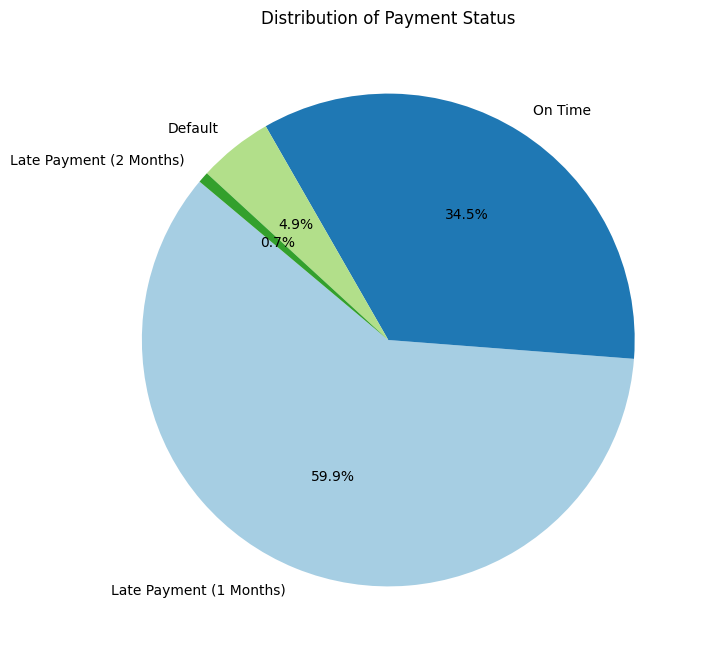

In [ ]:
# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(payment_status_counts, labels=payment_status_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Payment Status')
plt.show()


###Luxury loan purpose

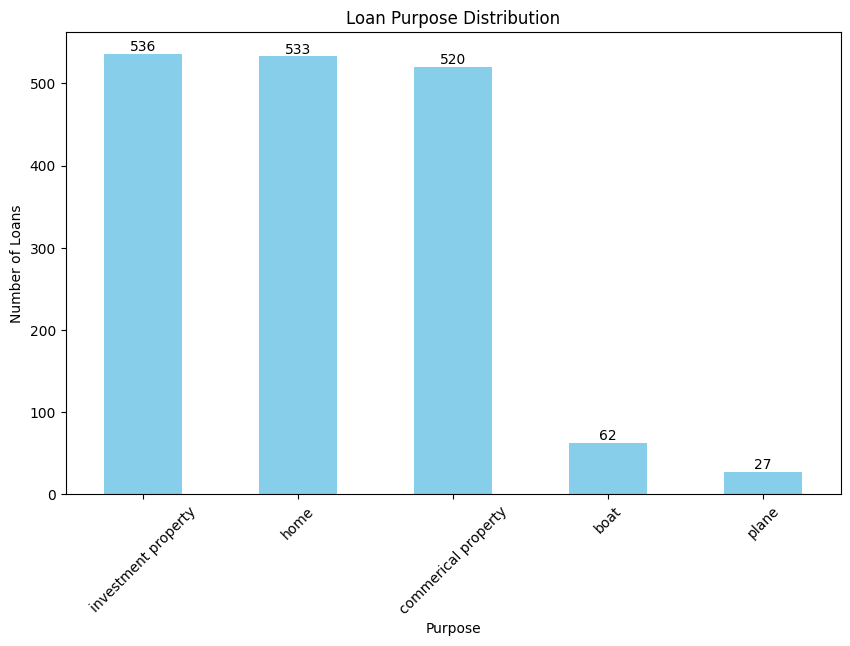

In [ ]:
# Step 2: Count the number of loans for each purpose
loan_purpose_counts = df_luxury_loan_portfolio['purpose'].value_counts()

# Step 3: Plot a bar diagram with data labels
plt.figure(figsize=(10, 6))
bars = loan_purpose_counts.plot(kind='bar', color='skyblue')

# Add data labels on top of each bar
for bar in bars.patches:
    plt.annotate(
        format(bar.get_height(), '.0f'),  # Format the label
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),  # Position of the label
        ha='center', va='bottom',  # Center alignment
        fontsize=10
    )

plt.title('Loan Purpose Distribution')
plt.xlabel('Purpose')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45)
plt.show()

###Employment length distribution

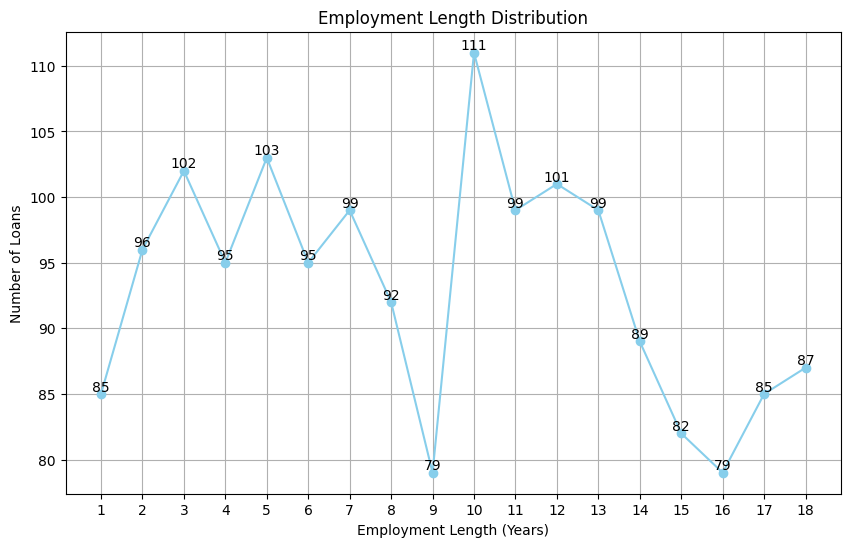

In [ ]:
# Step 2: Count the number of loans for each employment length
employment_length_counts = df_luxury_loan_portfolio['employment_length'].value_counts().sort_index()  # Sort by length

# Step 3: Plot a line chart with data labels
plt.figure(figsize=(10, 6))
plt.plot(employment_length_counts.index, employment_length_counts.values, marker='o', color='skyblue', linestyle='-')

# Add data labels on top of each point
for i, value in enumerate(employment_length_counts.values):
    plt.annotate(
        format(value, '.0f'),  # Format the label
        (employment_length_counts.index[i], value),  # Position of the label
        ha='center', va='bottom',  # Center alignment
        fontsize=10
    )

plt.title('Employment Length Distribution')
plt.xlabel('Employment Length (Years)')
plt.ylabel('Number of Loans')
plt.xticks(employment_length_counts.index)  # Ensure all employment lengths are shown
plt.grid(True)
plt.show()

##Yearly & Monthly Default Rate

In [ ]:
df_luxury_loan_defrate = df_luxury_loan_eda.copy()

In [ ]:
# Adding column 'funded_year' and 'funded_quarter'
df_luxury_loan_defrate['funded_year'] = df_luxury_loan_defrate['funded_date'].dt.year
df_luxury_loan_defrate['funded_month'] = df_luxury_loan_defrate['funded_date'].dt.to_period('M')

# Change 'status' as binary column : 1 for 'default', 0 for 'not default'
df_luxury_loan_defrate['default_flag'] = df_luxury_loan_defrate['status'].apply(lambda x: 1 if x == 'Default' else 0)

# Calculate default rate yearly and monthly
default_rate_per_monthly = df_luxury_loan_defrate.groupby('funded_month')['default_flag'].sum()
default_rate_per_year = df_luxury_loan_defrate.groupby('funded_year')['default_flag'].sum()

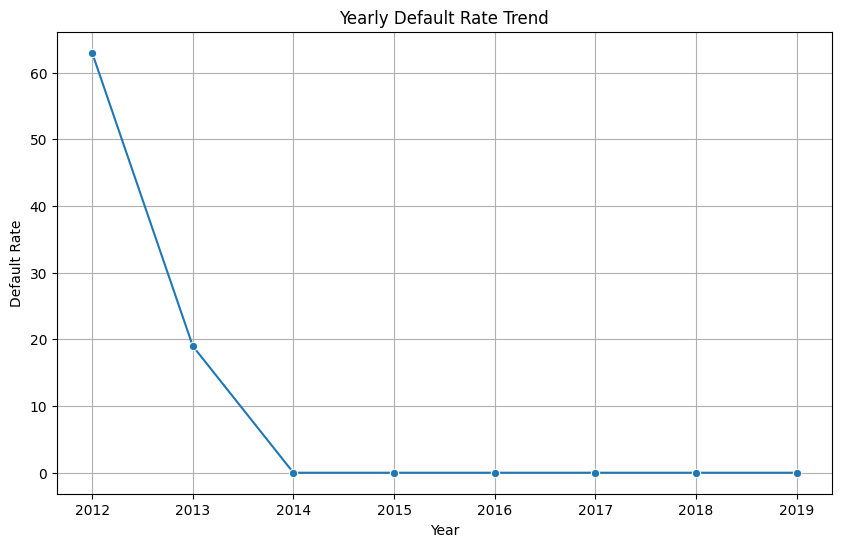

In [ ]:
# Visualisasi
plt.figure(figsize=(10, 6))
sns.lineplot(x=default_rate_per_year.index, y=default_rate_per_year.values, marker='o')
plt.title("Yearly Default Rate Trend")
plt.ylabel("Default Rate")
plt.xlabel("Year")
plt.grid()
plt.show()

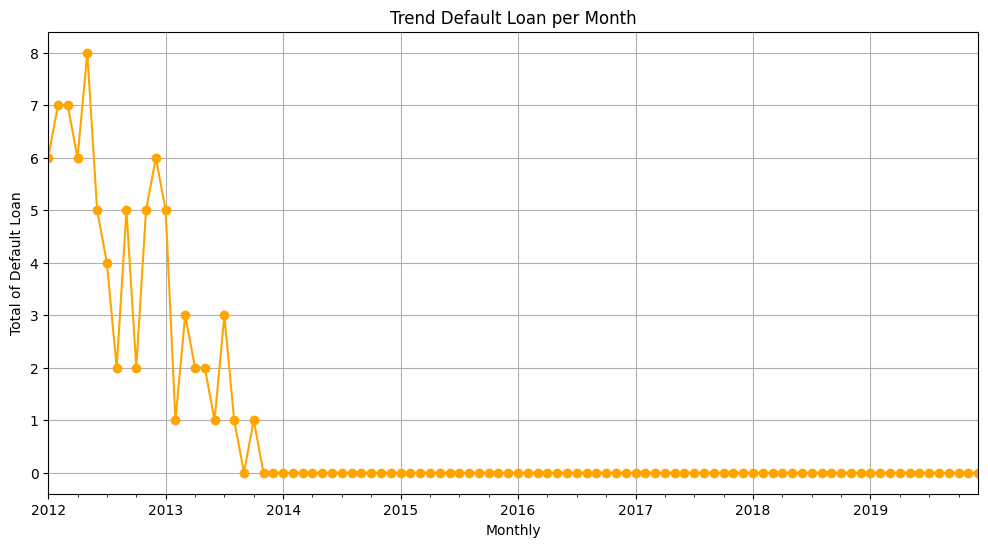

In [ ]:
# Visualisasi default rate per month
plt.figure(figsize=(12, 6))
default_rate_per_monthly.plot(kind='line', marker='o', color='orange')
plt.title("Trend Default Loan per Month")
plt.ylabel("Total of Default Loan")
plt.xlabel("Monthly")
plt.grid()
plt.show()

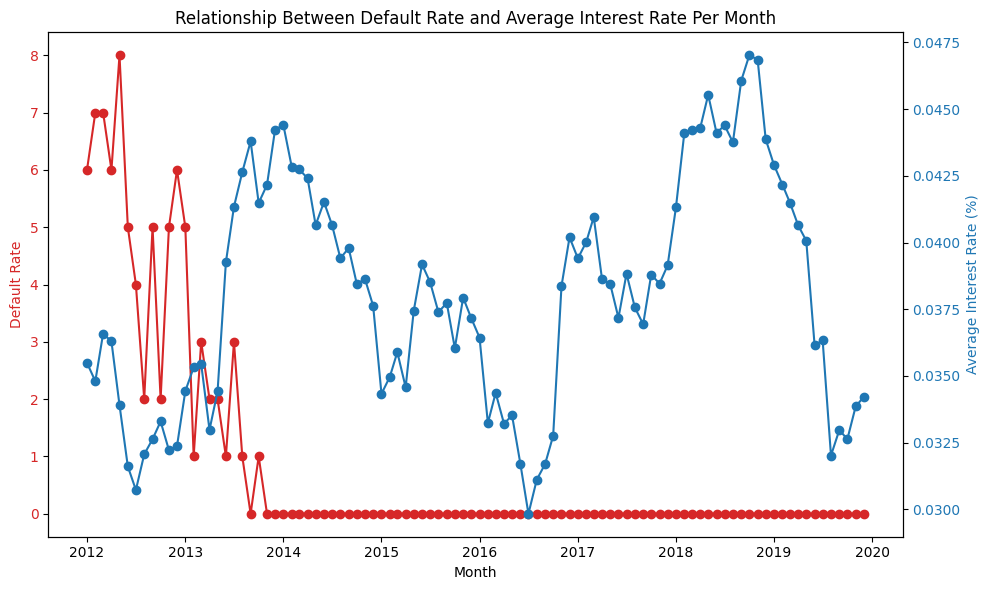

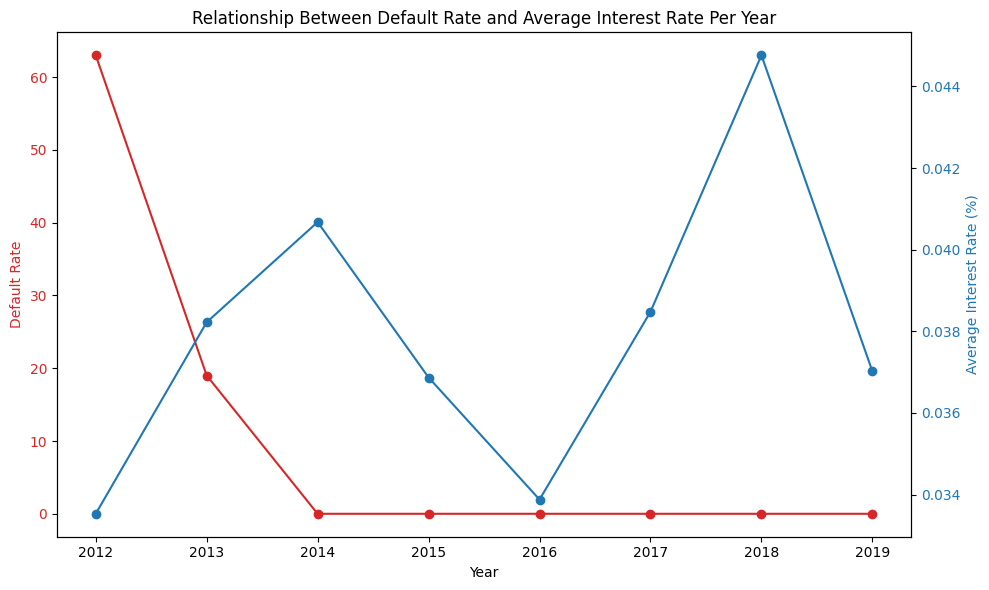

In [ ]:
# Calculate average interest_rate_percent and default rate per month
avg_interest_default = df_luxury_loan_defrate.groupby('funded_month').agg({
    'interest_rate': 'mean',
    'default_flag': 'sum'
}).reset_index()

# Convert 'funded_month' to datetime for plotting
avg_interest_default['funded_month'] = avg_interest_default['funded_month'].dt.to_timestamp()

# Calculate default rate and average interest rate per year
default_rate_per_year = df_luxury_loan_defrate.groupby('funded_year').agg({
    'default_flag': 'sum',
    'interest_rate': 'mean'
}).reset_index()

# Visualization for Month-Level Data using 2 y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Default Rate
ax1.set_title('Relationship Between Default Rate and Average Interest Rate Per Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('Default Rate', color='tab:red')
ax1.plot(avg_interest_default['funded_month'], avg_interest_default['default_flag'], color='tab:red', marker='o', label='Default Rate')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Add a second y-axis for interest_rate_percent
ax2 = ax1.twinx()
ax2.set_ylabel('Average Interest Rate (%)', color='tab:blue')
ax2.plot(avg_interest_default['funded_month'], avg_interest_default['interest_rate'], color='tab:blue', marker='o', label='Interest Rate')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()
plt.show()

# Visualization for Year-Level Data using 2 y-axes
fig, ax3 = plt.subplots(figsize=(10, 6))

# Plot Default Rate per Year
ax3.set_title('Relationship Between Default Rate and Average Interest Rate Per Year')
ax3.set_xlabel('Year')
ax3.set_ylabel('Default Rate', color='tab:red')
ax3.plot(default_rate_per_year['funded_year'], default_rate_per_year['default_flag'], color='tab:red', marker='o', label='Default Rate')
ax3.tick_params(axis='y', labelcolor='tab:red')

# Add a second y-axis for interest_rate_percent per year
ax4 = ax3.twinx()
ax4.set_ylabel('Average Interest Rate (%)', color='tab:blue')
ax4.plot(default_rate_per_year['funded_year'], default_rate_per_year['interest_rate'], color='tab:blue', marker='o', label='Interest Rate')
ax4.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()
plt.show()


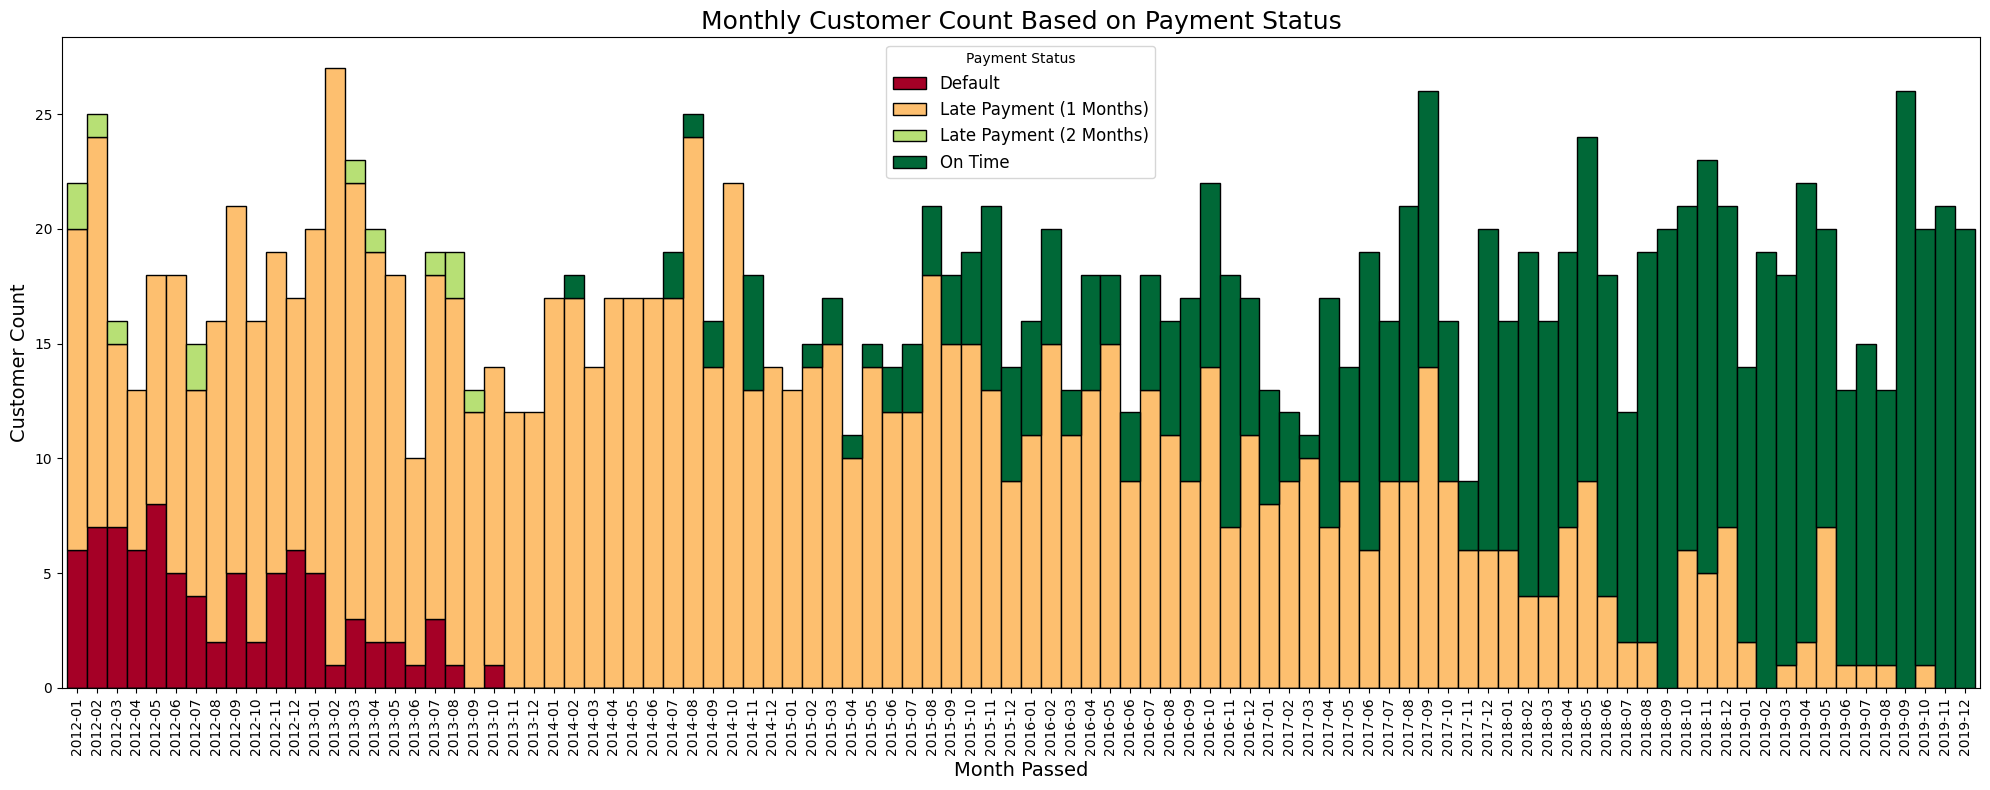

In [ ]:
# Grouping data by 'funded_month' and 'payment_status' to get customer count
monthly_payment_status = df_luxury_loan_defrate.groupby(['funded_month', 'payment_status']).size().reset_index(name='customer_count')

# Pivot the data to prepare for stacked bar chart
pivot_payment_status = monthly_payment_status.pivot(index='funded_month', columns='payment_status', values='customer_count').fillna(0)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(20, 8))

# Plotting the stacked bars
pivot_payment_status.plot(kind='bar', stacked=True, ax=ax, colormap= 'RdYlGn', edgecolor='k', width=1.0)

# Formatting x-axis to match the style in the provided chart
ax.set_title("Monthly Customer Count Based on Payment Status", fontsize=18)
ax.set_xlabel("Month Passed", fontsize=14)
ax.set_ylabel("Customer Count", fontsize=14)

# Adjust layout
plt.legend(title="Payment Status", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
df_luxury_loan_defrate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1678 entries, 0 to 1677
Data columns (total 39 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   loan_id                           1678 non-null   object        
 1   funded_amount                     1678 non-null   float64       
 2   funded_date                       1678 non-null   datetime64[ns]
 3   duration_years                    1678 non-null   int64         
 4   duration_months                   1678 non-null   int64         
 5   10_yr_treasury_index_date_funded  1678 non-null   float64       
 6   interest_rate_percent             1678 non-null   float64       
 7   interest_rate                     1678 non-null   float64       
 8   payments                          1678 non-null   float64       
 9   total_past_payments               1678 non-null   int64         
 10  loan_balance                      1678 non-null 

## Handling Outliers

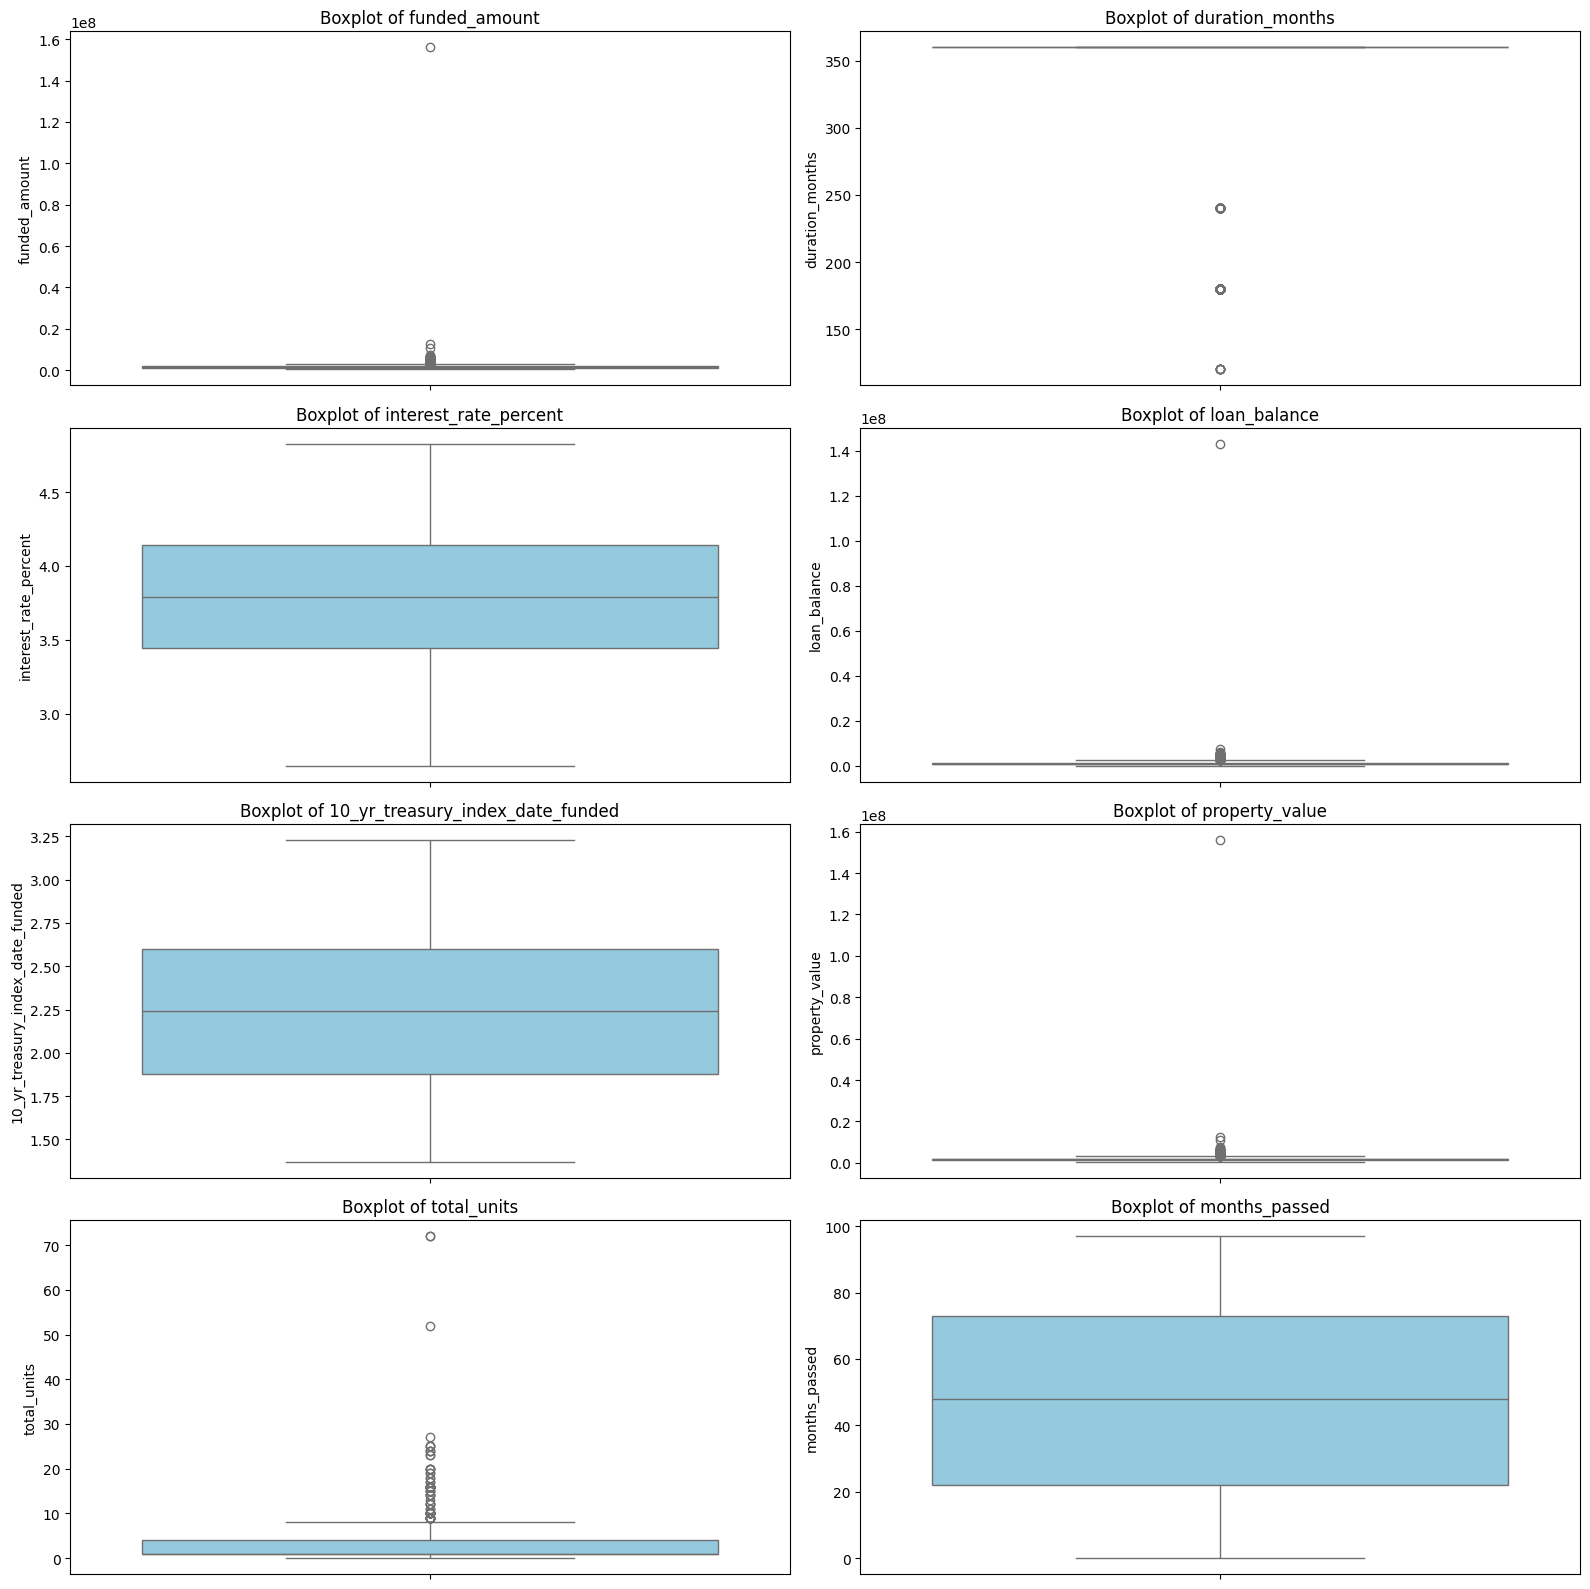

In [ ]:
# Select the relevant columns for outlier analysis
df_check_outliers = df_luxury_loan_eda[['funded_amount', 'duration_months', 'interest_rate_percent',
                                        'loan_balance', '10_yr_treasury_index_date_funded',
                                        'property_value', 'total_units', 'months_passed']]

# Create a 4x2 grid for boxplots
plt.figure(figsize=(16, 16))  # Set the figure size to ensure clear visualization

# Iterate through each column in the dataframe
for i, column in enumerate(df_check_outliers.columns, 1):  # Start index for subplots at 1
    plt.subplot(4, 2, i)  # Create a 4x2 grid for subplots
    sns.boxplot(y=df_check_outliers[column], color="skyblue")  # Plot boxplot for each column
    plt.title(f"Boxplot of {column}")  # Set the title for each boxplot

# Adjust layout to prevent overlap between subplots
plt.tight_layout()

# Display the plot
plt.show()

##Luxury Loan Segmentation

### Merge DataFrame

In [ ]:
df_luxury_loan_segmentation = df_luxury_loan_eda.copy()

In [ ]:
df_client_segmentation = df_completed_client.copy()

In [ ]:
print(df_luxury_loan_segmentation['social'].head())
print(df_client_segmentation['social'].head())

0    972-69-4236
1    577-13-5838
2    263-55-1721
3    512-60-5121
4    271-64-4634
Name: social, dtype: object
0    926-93-2157
1    806-94-5725
2    614-70-9100
3    580-20-3414
4    536-14-5809
Name: social, dtype: object


In [ ]:
# Step 1: Join df_luxury_loan_segmentation with df_completed_client on 'social'
df_luxloan_client = df_luxury_loan_segmentation.merge(df_client_segmentation, on='social', how='inner')

print(df_luxloan_client.shape)

(0, 55)


In [ ]:
df_luxloan_client_debug = df_luxury_loan_segmentation.merge(df_client_segmentation, on='social', how='outer', indicator=True)
print(df_luxloan_client_debug['_merge'].value_counts())

_merge
right_only    5369
left_only     1678
both             0
Name: count, dtype: int64


*Based on the _merge results:*

* right_only: 5369 → These rows exist only in df_client_segmentation.
* left_only: 1678 → These rows exist only in df_luxury_loan_segmentation.
* both: 0 → There are no matching social values between the two DataFrames.

*This confirms that there is no overlap in the social column between df_luxury_loan_segmentation and df_client_segmentation.*

### Selecting Numerical Column for Segmentation

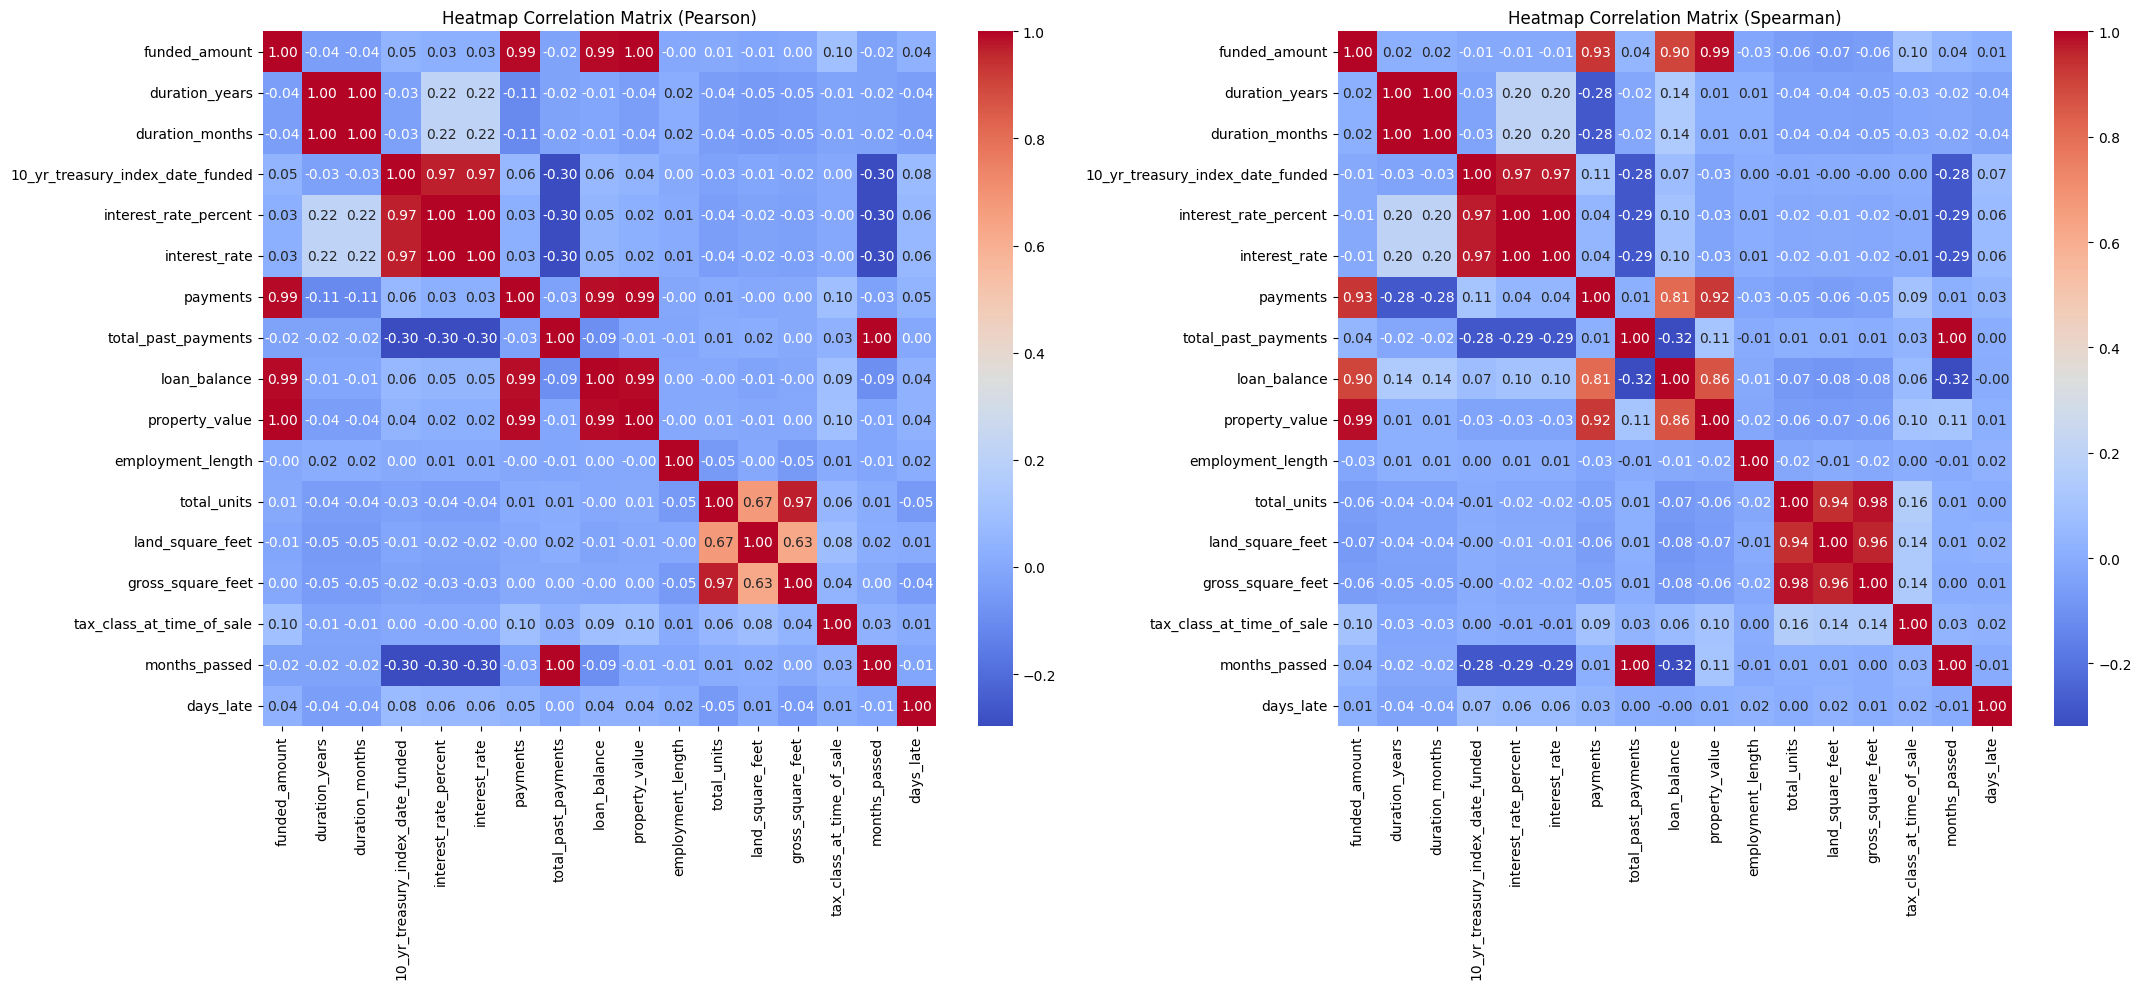

In [ ]:
# Select only numerical columns from the DataFrame
numeric_df = df_luxury_loan_segmentation.select_dtypes(include=['number'])

# Calculate Pearson and Spearman correlations
pearson_corr = numeric_df.corr(method='pearson')  # Pearson correlation
spearman_corr = numeric_df.corr(method='spearman')  # Spearman correlation

# Create a figure and axes with 2 columns to display the heatmaps side by side
fig, ax = plt.subplots(1, 2, figsize=(22, 10))  # 1 row, 2 columns

# Plot Pearson Heatmap
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[0])  # Pearson heatmap on the first subplot
ax[0].set_title("Heatmap Correlation Matrix (Pearson)")  # Title for Pearson heatmap

# Plot Spearman Heatmap
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=ax[1])  # Spearman heatmap on the second subplot
ax[1].set_title("Heatmap Correlation Matrix (Spearman)")  # Title for Spearman heatmap

# Display the plot
plt.tight_layout()  # Adjust layout to avoid overlap between plots
plt.show()


**Insights**

Columns to Keep (For Next Analysis):

1. funded_amount: Key variable for funding analysis.
2. loan_balance: Highly correlated with funded_amount, essential for financial tracking.
3. property_value: Important for understanding collateral value.
4. interest_rate or interest_rate_percent: Keep one, as they are perfectly correlated.

Columns to Drop (Due to Redundancy or Weak Correlation):
1. duration_months or duration_years: Perfectly correlated; keep one.
2. interest_rate_percent: Redundant with interest_rate.
3. employment_length and tax_class_at_time_of_sale: Low correlation with other variables, potentially not impactful.


In [ ]:
print("Unique values in land_square_feet:", df_luxury_loan_segmentation['land_square_feet'].nunique())
print("Percentage of zeros in land_square_feet:",
      (df_luxury_loan_segmentation['land_square_feet'] == 0).sum() / len(df_luxury_loan_segmentation) * 100)

print("Unique values in gross_square_feet:", df_luxury_loan_segmentation['gross_square_feet'].nunique())
print("Percentage of zeros in gross_square_feet:",
      (df_luxury_loan_segmentation['gross_square_feet'] == 0).sum() / len(df_luxury_loan_segmentation) * 100)

Unique values in land_square_feet: 201
Percentage of zeros in land_square_feet: 70.1430274135876
Unique values in gross_square_feet: 293
Percentage of zeros in gross_square_feet: 70.20262216924911


### Feature Scalling

In [ ]:
# Mapping the payment status to numerical values
payment_status_mapping = {
    'Default' : 3,
    'Late Payment (1 Months)': 1,
    'Late Payment (2 Months)': 2,
    'On Time': 0
}

# Add the 'payment_status_flag' column by mapping the 'payment_status' column
df_luxury_loan_segmentation['payment_status_flag'] = df_luxury_loan_segmentation['payment_status'].map(payment_status_mapping)

In [ ]:
df_luxury_loan_segmentation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1678 entries, 0 to 1677
Data columns (total 37 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   loan_id                           1678 non-null   object        
 1   funded_amount                     1678 non-null   float64       
 2   funded_date                       1678 non-null   datetime64[ns]
 3   duration_years                    1678 non-null   int64         
 4   duration_months                   1678 non-null   int64         
 5   10_yr_treasury_index_date_funded  1678 non-null   float64       
 6   interest_rate_percent             1678 non-null   float64       
 7   interest_rate                     1678 non-null   float64       
 8   payments                          1678 non-null   float64       
 9   total_past_payments               1678 non-null   int64         
 10  loan_balance                      1678 non-null 

In [ ]:
# Find the index of the row with the highest 'funded_amount'
max_funded_index = df_luxury_loan_segmentation['funded_amount'].idxmax()

# Drop the row with the highest 'funded_amount'
df_luxury_loan_segmentation = df_luxury_loan_segmentation.drop(index=max_funded_index)


In [ ]:
# Standart Saler
from sklearn.preprocessing import StandardScaler

numerical_columns = ['funded_amount', 'loan_balance', 'property_value',
                     'interest_rate_percent', '10_yr_treasury_index_date_funded',
                     'employment_length', 'months_passed', 'payment_status_flag']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_luxury_loan_segmentation[numerical_columns])

### K-Means Initial Approach

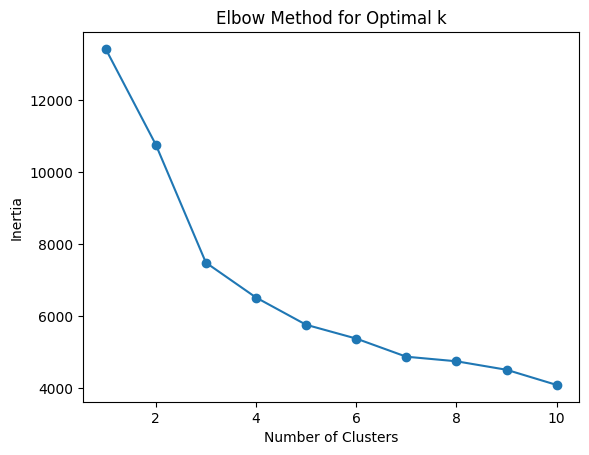

In [ ]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


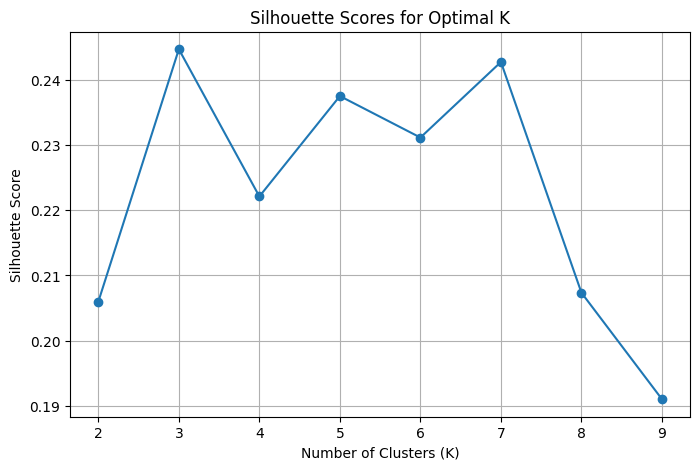

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 10):  # Silhouette requires at least two clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), sil_scores, marker='o')
plt.title('Silhouette Scores for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
sil_scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Print all scores
for idx, score in enumerate(sil_scores):
    print(f"For k={idx + 2}, the average silhouette score is {score:.4f}")

For k=2, the average silhouette score is 0.2060
For k=3, the average silhouette score is 0.2447
For k=4, the average silhouette score is 0.2221
For k=5, the average silhouette score is 0.2375
For k=6, the average silhouette score is 0.2311
For k=7, the average silhouette score is 0.2427
For k=8, the average silhouette score is 0.2073
For k=9, the average silhouette score is 0.1910


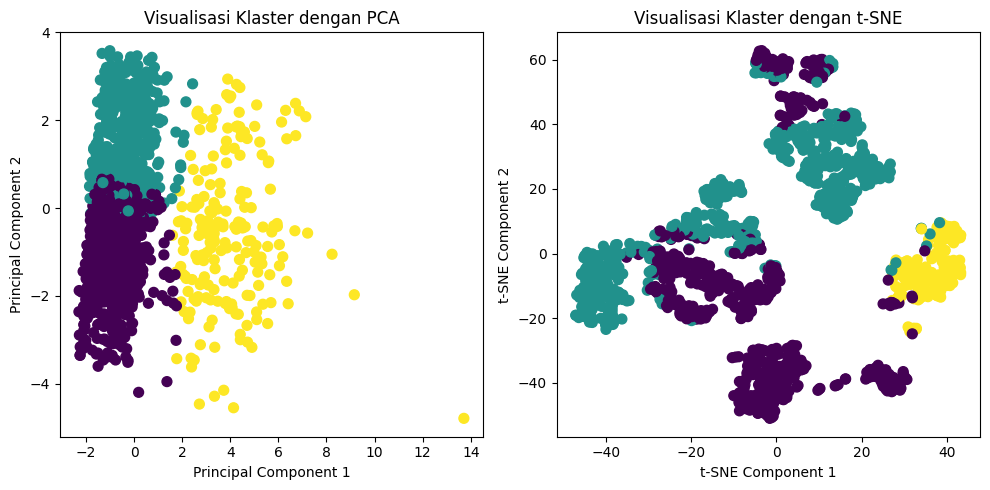

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 2. Clustering dengan KMeans
# Menentukan jumlah klaster optimal (dari elbow method sebelumnya)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

# 3. Visualisasi PCA
pca = PCA(n_components=2)  # Reduksi ke 2 dimensi
X_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Visualisasi Klaster dengan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 4. Visualisasi t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_scaled)

plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Visualisasi Klaster dengan t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

###Clustering

In [ ]:
import plotly.express as px
from sklearn.cluster import KMeans
import pandas as pd

# Assuming df_scaled and df_luxury_loan_segmentation are already defined

# Perform KMeans clustering (replace 7 with your optimal k)
kmeans = KMeans(n_clusters=3, random_state=42)  # Example with 7 clusters
kmeans.fit(df_scaled)

# Assign the cluster labels to the DataFrame
df_luxury_loan_segmentation['Cluster'] = kmeans.labels_

# Create a 3D scatter plot using Plotly
fig = px.scatter_3d(
    df_luxury_loan_segmentation,
    x='funded_amount',  # Replace with your actual column names
    y='interest_rate',  # Replace with your actual column names
    z='months_passed',  # Replace with your actual column names
    color='Cluster',  # Cluster column as the color
    color_continuous_scale='YlGnBu',
    title='3D Scatter Plot of Loan Segments'
)


# Show the plot
fig.show()


In [ ]:
# Assuming df_scaled and df_luxury_loan_segmentation are already defined

# Perform KMeans clustering (replace 7 with your optimal k)
kmeans = KMeans(n_clusters=3, random_state=42)  # Example with 4 clusters
kmeans.fit(df_scaled)

# Assign the cluster labels to the DataFrame
df_luxury_loan_segmentation['Cluster'] = kmeans.labels_

# Create a 3D scatter plot using Plotly with a blue-teal color palette
fig = px.scatter_3d(
    df_luxury_loan_segmentation,
    x='interest_rate',  # Replace with your actual column names
    y='funded_amount',  # Replace with your actual column names
    z='months_passed',  # Replace with your actual column names
    color='Cluster',  # Cluster column as the color
    color_continuous_scale='YlGnBu',  # Use the blue-teal color scale
    title='3D Scatter Plot of Loan Segments'
)

# Show the plot
fig.show()


In [ ]:
# Let's try to do grouping by the cluster created
segmentation_final = df_luxury_loan_segmentation.groupby('Cluster').agg({
                    'funded_amount' : 'median',
                    'loan_balance' : 'median',
                    'duration_months' : 'mean',
                    '10_yr_treasury_index_date_funded' : 'mean',
                    'interest_rate_percent' : 'mean',
                    'months_passed' : 'mean',
                    'employment_length' : 'mean'
})

segmentation_final

,funded_amount,loan_balance,duration_months,10_yr_treasury_index_date_funded,interest_rate_percent,months_passed,employment_length
Cluster,,,,,,,
0,1430000.00,962073.65,325.55,1.90,3.44,59.16,9.31
1,1400000.00,1103748.02,331.54,2.60,4.15,37.09,9.45
2,4356000.00,3344982.15,327.30,2.26,3.80,46.42,8.86


In [ ]:
df_luxury_loan_segmentation.to_excel('luxury_loan_segmentation.xlsx', index=False)

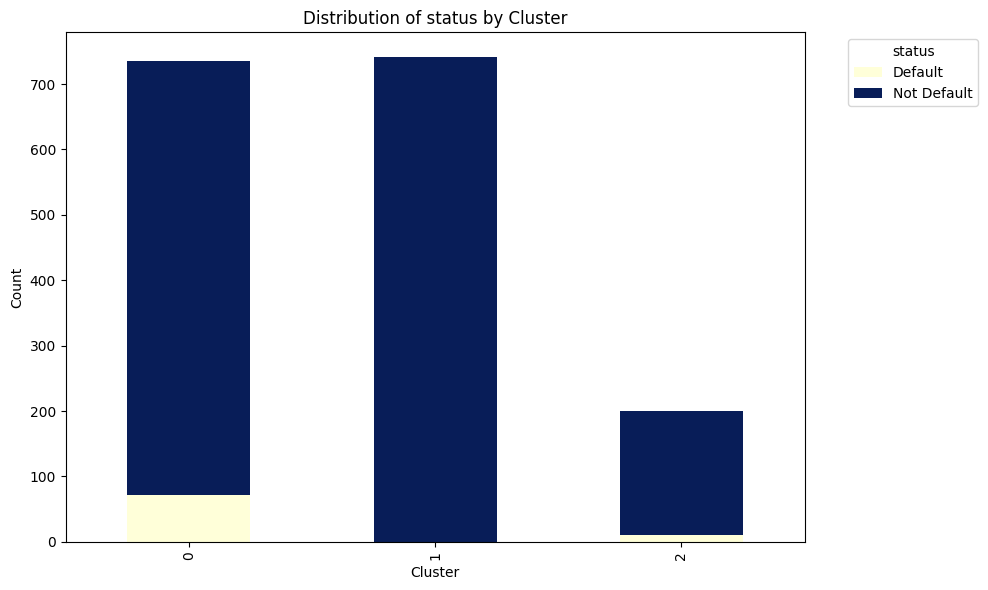

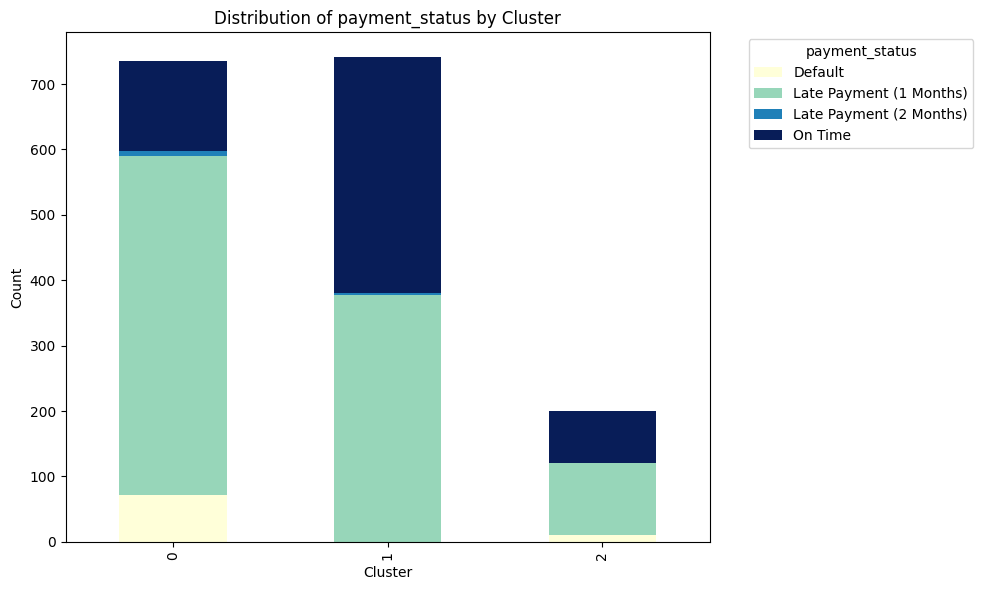

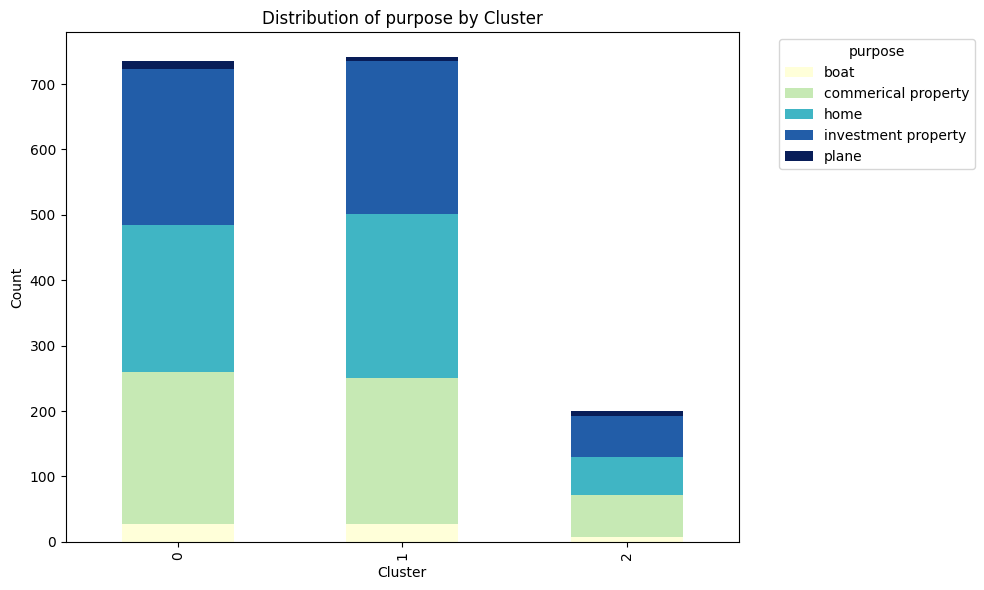

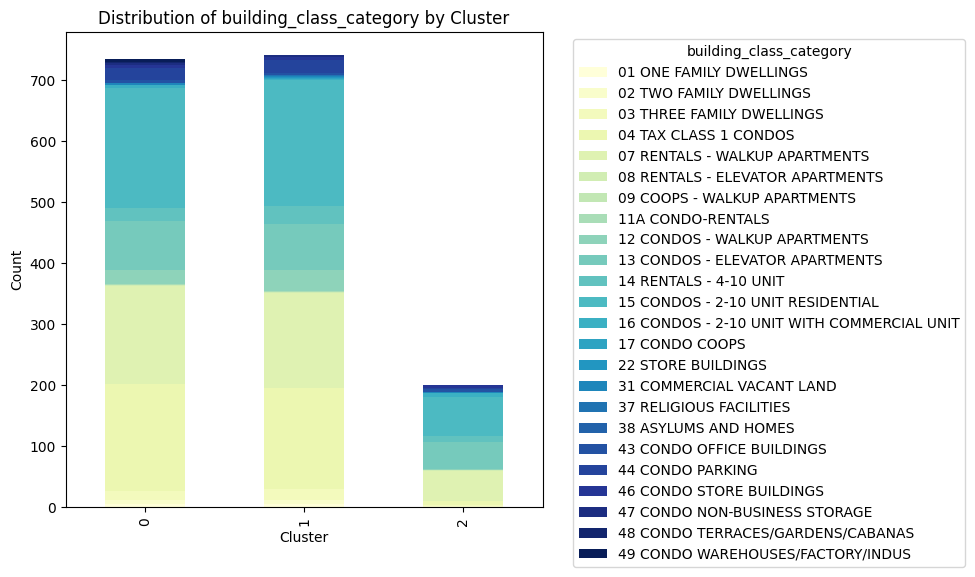

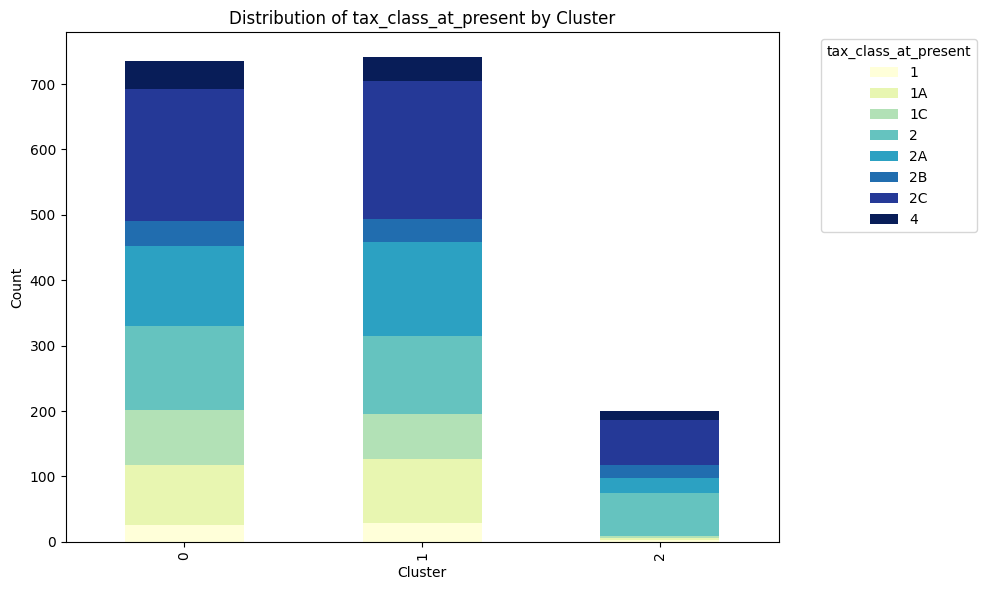

In [ ]:
import seaborn as sns

# List of categorical columns
categorical_columns = ['status', 'payment_status', 'purpose',
                       'building_class_category', 'tax_class_at_present']

# Loop through each categorical column
for col in categorical_columns:
    plt.figure(figsize=(10, 6))  # Set figure size

    # Cross-tabulation for counts by cluster
    cluster_counts = pd.crosstab(df_luxury_loan_segmentation['Cluster'], df_luxury_loan_segmentation[col])

    # Plot as a stacked bar chart
    cluster_counts.plot(kind='bar', stacked=True, colormap='YlGnBu', ax=plt.gca())

    # Customize the plot
    plt.title(f'Distribution of {col} by Cluster')
    plt.ylabel('Count')
    plt.xlabel('Cluster')
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()  # Adjust layout to fit the legend

    # Show the chart
    plt.show()


##Luxury loan Regression (Predicting Default Rate)


#Loan

##Understanding Dataset

In [ ]:
df_completed_loan.shape
print('Number of rows is: ', df_completed_loan.shape[0])
print('Number of columns is: ', df_completed_loan.shape[1])

Number of rows is:  682
Number of columns is:  13


In [ ]:
df_completed_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   loan_id     682 non-null    int64 
 1   account_id  682 non-null    object
 2   amount      682 non-null    int64 
 3   duration    682 non-null    int64 
 4   payments    682 non-null    int64 
 5   status      682 non-null    object
 6   year        682 non-null    int64 
 7   month       682 non-null    int64 
 8   day         682 non-null    int64 
 9   fulldate    682 non-null    object
 10  location    682 non-null    int64 
 11  purpose     682 non-null    object
 12  date        682 non-null    object
dtypes: int64(8), object(5)
memory usage: 69.4+ KB


##Convert Data Type

In [ ]:
# Convert 'fulldate' and 'date' to datetime format
df_completed_loan['fulldate'] = pd.to_datetime(df_completed_loan['fulldate'])

# Convert 'location', 'status', and 'purpose' to category
df_completed_loan['location'] = df_completed_loan['location'].astype('category')
df_completed_loan['status'] = df_completed_loan['status'].astype('category')
df_completed_loan['purpose'] = df_completed_loan['purpose'].astype('category')

##Handling missing data, irrelevant data, and duplicate

*There's no missing data*

In [ ]:
# Number of missing values in each column
df_completed_loan.isnull().sum()

,0
loan_id,0
account_id,0
amount,0
duration,0
payments,0
status,0
year,0
month,0
day,0
fulldate,0


*We will be checking for typos in specific columns of a dataset. The columns we will be checking are:*

* Status
* Location
* Purpose

In [ ]:
# Count the values
list_obj = ['status', 'location', 'purpose']

for i in list_obj:
    unique_data = df_completed_loan[i].value_counts()
    print(unique_data.to_markdown(), '\n\n')

| status   |   count |
|:---------|--------:|
| C        |     403 |
| A        |     203 |
| D        |      45 |
| B        |      31 | 


|   location |   count |
|-----------:|--------:|
|          1 |     507 |
|         64 |      75 |
|         59 |      55 |
|         18 |      21 |
|         70 |      14 |
|         46 |       5 |
|         29 |       3 |
|         25 |       2 | 


| purpose            |   count |
|:-------------------|--------:|
| home               |     537 |
| debt_consolidation |      75 |
| home_improvement   |      40 |
| car                |      30 | 




**Based on the loan statuses:**

* A (Active): Loan is still ongoing with regular payments.
* B (Behind): Loan is overdue but not yet defaulted.
* C (Complete): Loan is fully repaid.
* D (Default): Loan has failed or the borrower cannot repay.

*No duplicated data*

In [ ]:
# Check the duplicated
df_completed_loan[df_completed_loan['loan_id'].duplicated()]

,loan_id,account_id,amount,duration,payments,status,year,month,day,fulldate,location,purpose,date


## Handling Outlier

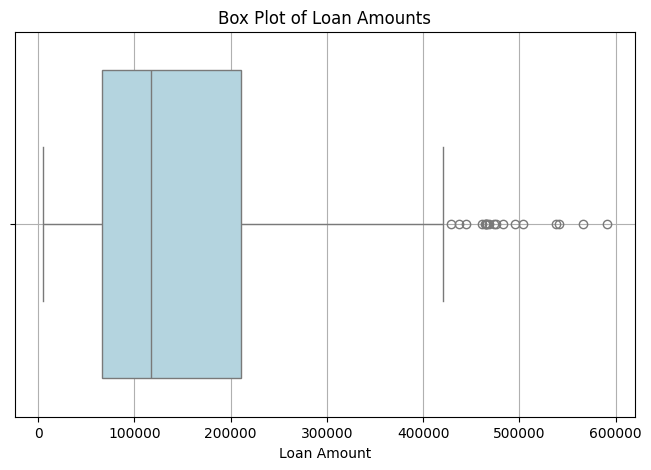

In [ ]:
# Set the figure size for better visibility
plt.figure(figsize=(8, 5))

# Create a box plot for the 'amount' column
sns.boxplot(x=df_completed_loan['amount'], color='lightblue')

# Customize the plot
plt.title('Box Plot of Loan Amounts')
plt.xlabel('Loan Amount')
plt.grid(True)  # Optional: Add grid for better readability

# Show the plot
plt.show()

*Outliers will remove for k-means analysis, but for simple EDA all outliers will be still kept*

##EDA

In [ ]:
df_loan_eda = df_completed_loan.copy()

###Numerical description

In [ ]:
numerical_loan = df_loan_eda.select_dtypes(include = ['number'])

pd.set_option('display.float_format', '{:.2f}'.format) # 2 angka dibelakang koma

desc_num_loan = numerical_loan.describe()

desc_num_loan.loc['kurtosis'] = numerical_loan.kurt()
desc_num_loan.loc['skew'] = numerical_loan.skew()

desc_num_loan

,loan_id,amount,duration,payments,year,month,day
count,682.00,682.00,682.00,682.00,682.00,682.00,682.00
mean,6172.47,151410.18,36.49,4190.66,2016.23,6.66,15.45
std,682.58,113372.41,17.08,2215.83,1.47,3.44,9.12
min,4959.00,4980.00,12.00,304.00,2013.00,1.00,1.00
25%,5577.50,66732.00,24.00,2477.00,2015.00,4.00,8.00
50%,6176.50,116928.00,36.00,3934.00,2017.00,7.00,15.00
75%,6752.50,210654.00,48.00,5813.50,2017.00,10.00,24.00
max,7308.00,590820.00,60.00,9910.00,2018.00,12.00,31.00
kurtosis,-1.22,0.84,-1.32,-0.70,-0.92,-1.17,-1.28
skew,-0.06,1.11,-0.03,0.35,-0.48,-0.06,0.10


###Caterogical desription

In [ ]:
categorical_loan = df_loan_eda.select_dtypes(exclude = ['number','datetime'])
categorical_loan.describe()

,account_id,status,location,purpose,date
count,682,682,682,682,682
unique,682,4,8,4,559
top,A00003354,C,1,home,2018-04-19
freq,1,403,507,537,4


###Loan status/default rate (Pie chart)

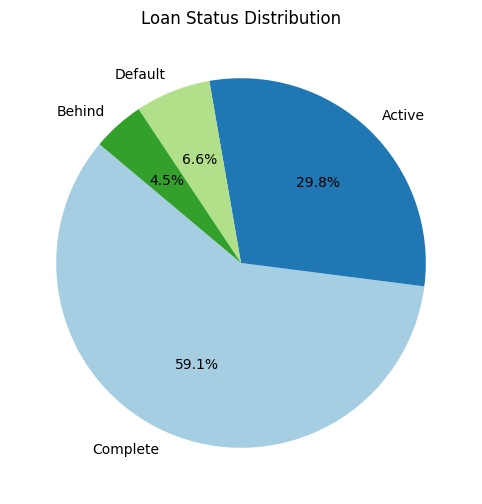

In [ ]:
# Map status to descriptive labels and store in a new column 'status_label'
status_labels = {'A': 'Active', 'B': 'Behind', 'C': 'Complete', 'D': 'Default'}
df_loan_eda['status_label'] = df_loan_eda['status'].map(status_labels)

# Count the occurrences of each status_label
status_counts = df_loan_eda['status_label'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Loan Status Distribution')
plt.show()

###Loan Purpose (Bar chart)

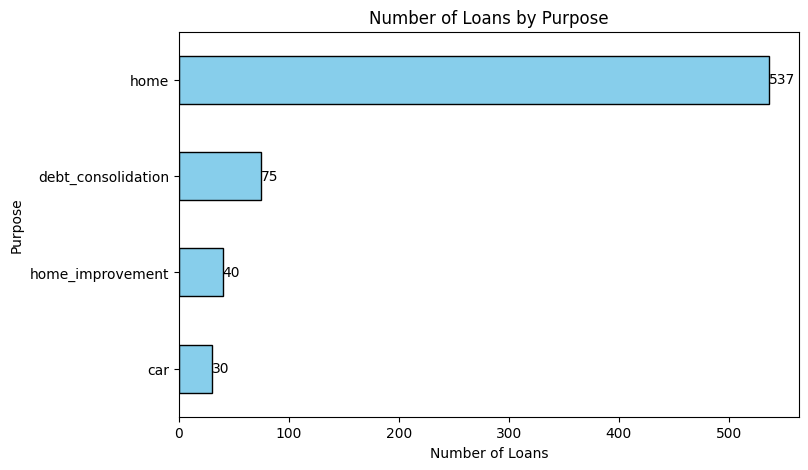

In [ ]:
# Count the number of loans for each purpose category and sort in descending order
purpose_counts = df_loan_eda['purpose'].value_counts().sort_values(ascending=True)

# Create a horizontal bar chart
plt.figure(figsize=(8, 5))
bars = purpose_counts.plot(kind='barh', color='skyblue', edgecolor='black')

# Add data labels on top of each bar
for bar in bars.patches:
    plt.annotate(
        format(bar.get_width(), '.0f'),  # Format the label
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),  # Position of the label
        ha='left', va='center',  # Alignment
        fontsize=10
    )

# Customize the chart
plt.title('Number of Loans by Purpose')
plt.xlabel('Number of Loans')
plt.ylabel('Purpose')
plt.show()


###Number of loans monthly

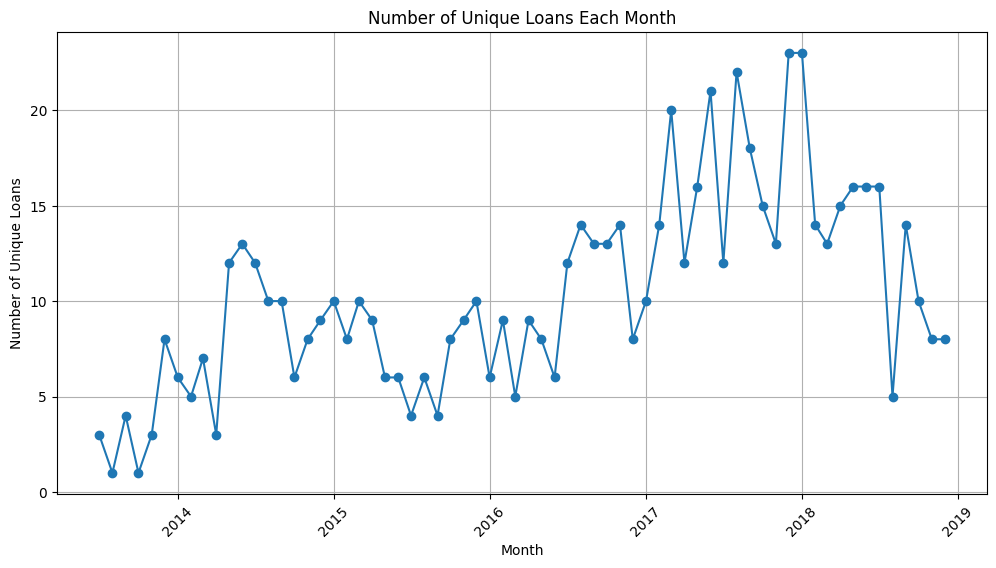

In [ ]:
# Convert 'fulldate' column to datetime format
df_loan_eda['fulldate'] = pd.to_datetime(df_loan_eda['fulldate'])

# Extract year and month from the 'fulldate'
df_loan_eda['year_month'] = df_loan_eda['fulldate'].dt.to_period('M')

# Count the number of unique loans for each year-month combination
monthly_loan_counts = df_loan_eda.groupby('year_month')['loan_id'].nunique()

# Plotting the line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_loan_counts.index.to_timestamp(), monthly_loan_counts.values, marker='o', linestyle='-')  # Convert to timestamp for plotting
plt.title('Number of Unique Loans Each Month')
plt.xlabel('Month')
plt.ylabel('Number of Unique Loans')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)
plt.show()

<ipython-input-72-cc4437fee882>:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



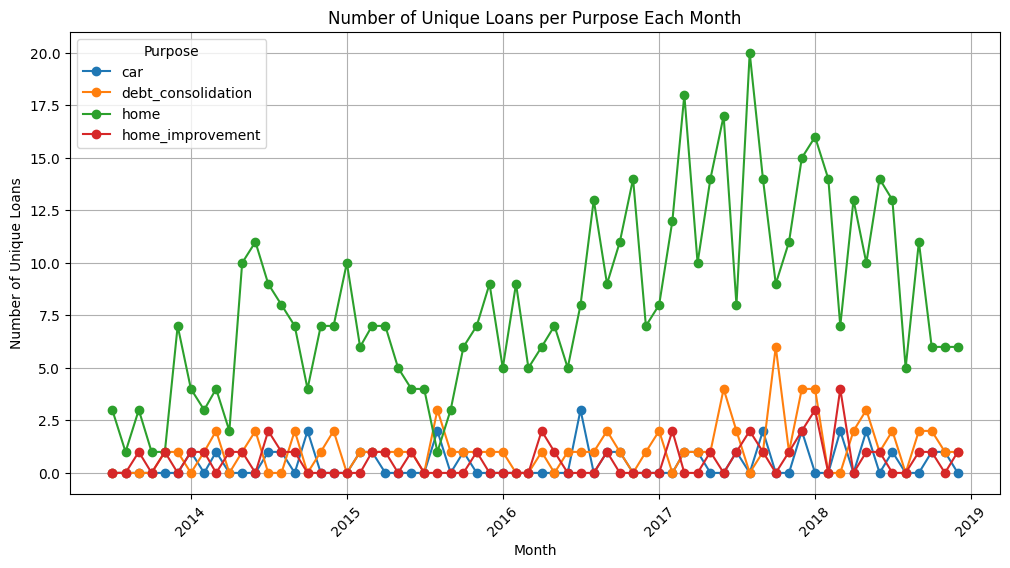

In [ ]:
# Group by 'year_month' and 'purpose', then count unique loan IDs
monthly_purpose_loan_counts = df_loan_eda.groupby(['year_month', 'purpose'])['loan_id'].nunique().reset_index()

# Pivot the data to get 'purpose' as columns for easier plotting
pivot_data = monthly_purpose_loan_counts.pivot(index='year_month', columns='purpose', values='loan_id')

# Plot the line chart for each purpose
plt.figure(figsize=(12, 6))
for purpose in pivot_data.columns:
    plt.plot(pivot_data.index.to_timestamp(), pivot_data[purpose], marker='o', linestyle='-', label=purpose)

# Customize the plot
plt.title('Number of Unique Loans per Purpose Each Month')
plt.xlabel('Month')
plt.ylabel('Number of Unique Loans')
plt.xticks(rotation=45)
plt.legend(title='Purpose')
plt.grid(True)
plt.show()


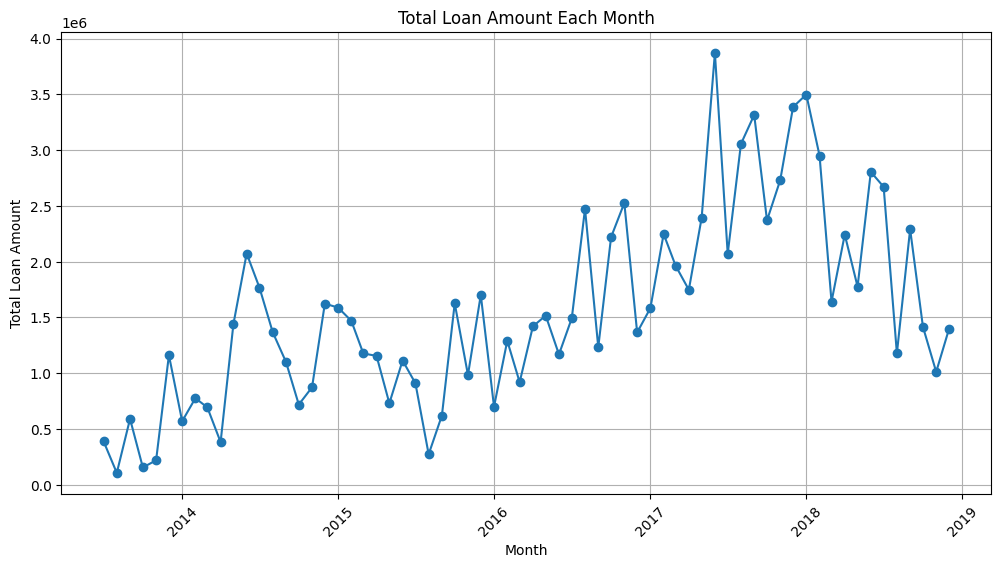

In [ ]:
# Sum the amount for each year-month combination
monthly_amount_counts = df_loan_eda.groupby('year_month')['amount'].sum()

# Plotting the line chart
plt.figure(figsize=(12, 6))
plt.plot(monthly_amount_counts.index.to_timestamp(), monthly_amount_counts, marker='o', linestyle='-')
plt.title('Total Loan Amount Each Month')
plt.xlabel('Month')
plt.ylabel('Total Loan Amount')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)
plt.show()


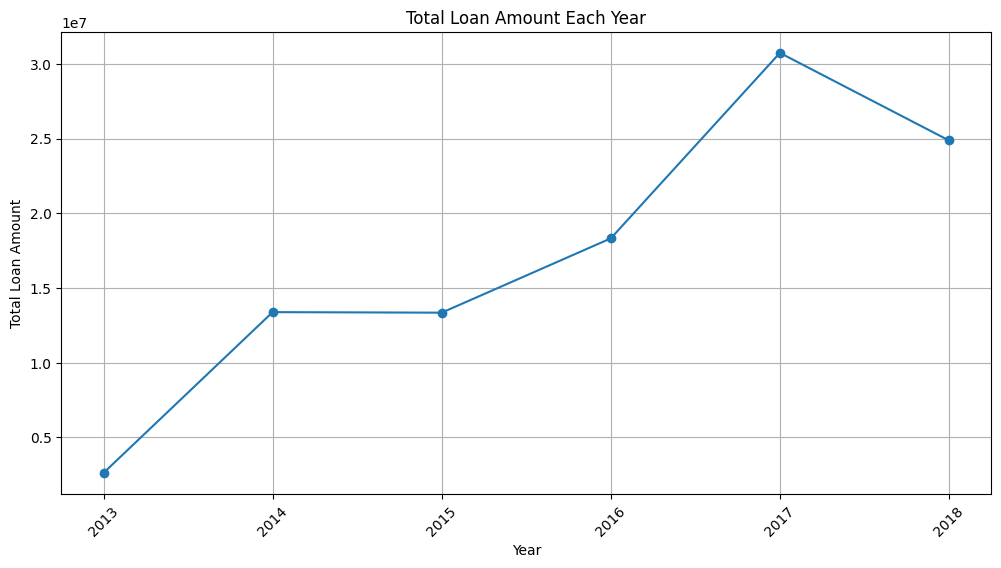

In [ ]:
# Sum the amount for each year
yearly_amount_counts = df_loan_eda.groupby('year')['amount'].sum()

# Plotting the line chart
plt.figure(figsize=(12, 6))
plt.plot(yearly_amount_counts.index, yearly_amount_counts, marker='o', linestyle='-')
plt.title('Total Loan Amount Each Year')
plt.xlabel('Year')
plt.ylabel('Total Loan Amount')
plt.xticks(yearly_amount_counts.index, rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)
plt.show()


##Data Preparation Segmentation Loan x Transaction X Client

In [ ]:
df_loan_segmentation = df_loan_eda.copy()

In [ ]:
# Mapping the payment status to numerical values
loan_status_mapping = {
    'A': 3,
    'B': 1,
    'C': 2,
    'D': 0
}

# Add the 'loan_status_flag' column by mapping the 'payment_status' column
df_loan_segmentation['loan_status_flag'] = df_loan_segmentation['status'].map(loan_status_mapping)

#Completed Transaction

##Understanding Dataset

In [ ]:
df_completed_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   column_a          1056320 non-null  int64  
 1   trans_id          1056320 non-null  object 
 2   account_id        1056320 non-null  object 
 3   type              1056320 non-null  object 
 4   operation         873206 non-null   object 
 5   amount            1056320 non-null  float64
 6   balance           1056320 non-null  float64
 7   k_symbol          574439 non-null   object 
 8   bank              273508 non-null   object 
 9   account           295389 non-null   float64
 10  year              1056320 non-null  int64  
 11  month             1056320 non-null  int64  
 12  day               1056320 non-null  int64  
 13  fulldate          1056320 non-null  object 
 14  fulltime          1056320 non-null  object 
 15  fulldatewithtime  1056320 non-null  object 
 16  

##Convert Data Type

In [ ]:
# Change data type to string
string_columns = ['trans_id', 'account_id', 'type', 'operation', 'k_symbol', 'bank']
df_completed_trans[string_columns] = df_completed_trans[string_columns].astype('string')

# Only want to store the date without the time (normalize to midnight).
df_completed_trans['fulldate'] = pd.to_datetime(df_completed_trans['fulldate'], errors='coerce')
df_completed_trans['fulldate'] = df_completed_trans['fulldate'].dt.normalize()

# Verification after change data type
print(df_completed_trans.dtypes)

column_a                     int64
trans_id            string[python]
account_id          string[python]
type                string[python]
operation           string[python]
amount                     float64
balance                    float64
k_symbol            string[python]
bank                string[python]
account                    float64
year                         int64
month                        int64
day                          int64
fulldate            datetime64[ns]
fulltime                    object
fulldatewithtime            object
date                        object
dtype: object


In [ ]:
# Try converting to datetime and identify the problematic rows
problematic_fulltime = df_completed_trans[
    pd.to_datetime(df_completed_trans['fulltime'], errors='coerce').isna()
]
problematic_fulldatewithtime = df_completed_trans[
    pd.to_datetime(df_completed_trans['fulldatewithtime'], errors='coerce').isna()
]

<ipython-input-79-355f473f67ae>:3: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [ ]:
problematic_fulltime [['fulltime']]

,fulltime
90,15:60:16
166,15:60:01
188,15:60:28
312,16:60:38
332,16:55:60
...,...
1056256,13:51:60
1056270,13:60:18
1056274,12:60:11
1056308,10:12:60


In [ ]:
problematic_fulldatewithtime [['fulldatewithtime']]

,fulldatewithtime
90,2013-01-21T15:60:16
166,2013-01-31T15:60:01
188,2013-02-02T15:60:28
312,2013-02-11T16:60:38
388,2013-02-18T15:60:15
...,...
1056165,2018-12-31T13:60:40
1056189,2018-12-31T09:60:21
1056196,2018-12-31T12:60:12
1056270,2018-12-31T13:60:18


In [ ]:
import re

def fix_time_format(time_str):
    """
    Fixes invalid time formats.
    Examples:
    - '16:55:60' -> '16:56:00'
    - '11:60:21' -> '12:00:21'
    """
    try:
        # Extract hours, minutes, and seconds
        match = re.match(r'(\d{2}):(\d{2}):(\d{2})', time_str)
        if not match:
            return time_str  # Return the original value if the format does not match

        hours, minutes, seconds = map(int, match.groups())

        # Fix seconds
        if seconds >= 60:
            minutes += seconds // 60
            seconds %= 60

        # Fix minutes
        if minutes >= 60:
            hours += minutes // 60
            minutes %= 60

        # Fix hours (24-hour overflow is not checked as the specification does not mention it)

        # Reformat the time
        return f"{hours:02}:{minutes:02}:{seconds:02}"
    except Exception:
        return time_str  # If an error occurs, return the original value

In [ ]:
# Apply the function to the 'fulltime' column
df_completed_trans['fulltime'] = df_completed_trans['fulltime'].apply(fix_time_format)

In [ ]:
# Fixes invalid time formats
def fix_time_format(time_str):
    date, time = time_str.split('T')
    hour, minute, second = map(int, time.split(':'))

      # Fix minutes and seconds
    if second >= 60:
        second = 0
        minute += 1
    if minute >= 60:
        minute = 0
        hour += 1

    # Reformat the time
    fixed_time = f"{hour:02}:{minute:02}:{second:02}"
    return f"{date}T{fixed_time}"

In [ ]:
# Apply the function to the 'fulldatewithtime' column
df_completed_trans['fulldatewithtime'] = df_completed_trans['fulldatewithtime'].apply(fix_time_format)

##Handling missing data, irrelevant data, and duplicate

In [ ]:
df_completed_trans.isnull().sum()

,0
column_a,0
trans_id,0
account_id,0
type,0
operation,183114
amount,0
balance,0
k_symbol,481881
bank,782812
account,760931


In [ ]:
# Find all occurrences of duplicates in 'trans_id'
all_duplicates = df_completed_trans[df_completed_trans['trans_id'].duplicated(keep=False)]
print(f"Total rows involved in duplicates: {all_duplicates.shape[0]}")
print(all_duplicates)


Total rows involved in duplicates: 0
Empty DataFrame
Columns: [column_a, trans_id, account_id, type, operation, amount, balance, k_symbol, bank, account, year, month, day, fulldate, fulltime, fulldatewithtime, date]
Index: []


In [ ]:
# Example of handling NaN explicitly
list_obj_client = ['type', 'operation', 'k_symbol']

for i in list_obj_client:
    # Ensure that NaN values are treated as a separate category
    if df_completed_trans[i].isnull().any():
        df_completed_trans[i] = df_completed_trans[i].fillna('NaN')  # Replace NaN with a string if necessary

    unique_data_trans = df_completed_trans[i].value_counts(dropna=False)
    print(unique_data_trans.to_markdown(), '\n\n')

| type   |   count |
|:-------|--------:|
| Debit  |  651237 |
| Credit |  405083 | 


| operation                    |   count |
|:-----------------------------|--------:|
| Cash Withdrawal              |  434918 |
| Remittance to Another Bank   |  208283 |
| NaN                          |  183114 |
| Credit in Cash               |  156743 |
| Collection from Another Bank |   65226 |
| Credit Card Withdrawal       |    8036 | 


| k_symbol             |   count |
|:---------------------|--------:|
| NaN                  |  481881 |
| Interest Credited    |  183114 |
| Payment on Statement |  155832 |
| Household            |  118065 |
|                      |   53433 |
| Old Age Pension      |   30338 |
| Insurance Payment    |   18500 |
| Loan Payment         |   13580 |
| Sanction Interest    |    1577 | 




In [ ]:
# Check and replace empty strings with NaN
df_completed_trans['k_symbol'] = df_completed_trans['k_symbol'].replace('', np.nan)

# Fill NaN values with the desired value
df_completed_trans['k_symbol'] = df_completed_trans['k_symbol'].fillna('DefaultValue')


In [ ]:
df_completed_trans

,column_a,trans_id,account_id,type,operation,amount,balance,k_symbol,bank,account,year,month,day,fulldate,fulltime,fulldatewithtime,date
0,1,T00695247,A00002378,Credit,Credit in Cash,700.00,700.00,NaN,<NA>,NaN,2013,1,1,2013-01-01,11:02:40,2013-01-01T11:02:40,2013-01-01
1,2,T00171812,A00000576,Credit,Credit in Cash,900.00,900.00,NaN,<NA>,NaN,2013,1,1,2013-01-01,08:23:33,2013-01-01T08:23:33,2013-01-01
2,3,T00207264,A00000704,Credit,Credit in Cash,1000.00,1000.00,NaN,<NA>,NaN,2013,1,1,2013-01-01,15:19:21,2013-01-01T15:19:21,2013-01-01
3,4,T01117247,A00003818,Credit,Credit in Cash,600.00,600.00,NaN,<NA>,NaN,2013,1,1,2013-01-01,10:42:35,2013-01-01T10:42:35,2013-01-01
4,5,T00579373,A00001972,Credit,Credit in Cash,400.00,400.00,NaN,<NA>,NaN,2013,1,2,2013-01-02,11:39:25,2013-01-02T11:39:25,2013-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1056315,1056316,T03626622,A00002906,Credit,NaN,62.30,13729.40,Interest Credited,<NA>,NaN,2018,12,31,2018-12-31,15:18:14,2018-12-31T15:18:14,2018-12-31
1056316,1056317,T03627616,A00002935,Credit,NaN,81.30,19544.90,Interest Credited,<NA>,NaN,2018,12,31,2018-12-31,13:05:00,2018-12-31T13:05:00,2018-12-31
1056317,1056318,T03625403,A00002869,Credit,NaN,60.20,14638.20,Interest Credited,<NA>,NaN,2018,12,31,2018-12-31,08:30:13,2018-12-31T08:30:13,2018-12-31
1056318,1056319,T03626683,A00002907,Credit,NaN,107.50,23453.00,Interest Credited,<NA>,NaN,2018,12,31,2018-12-31,14:45:19,2018-12-31T14:45:19,2018-12-31


##EDA

In [ ]:
df_completed_trans_eda = df_completed_trans.copy()

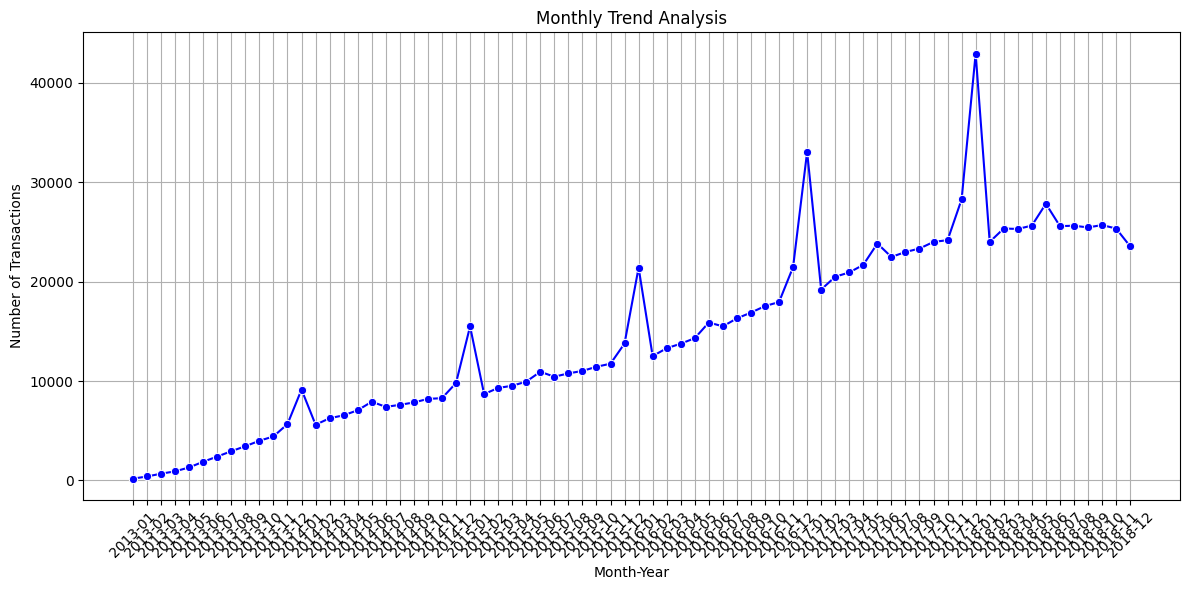

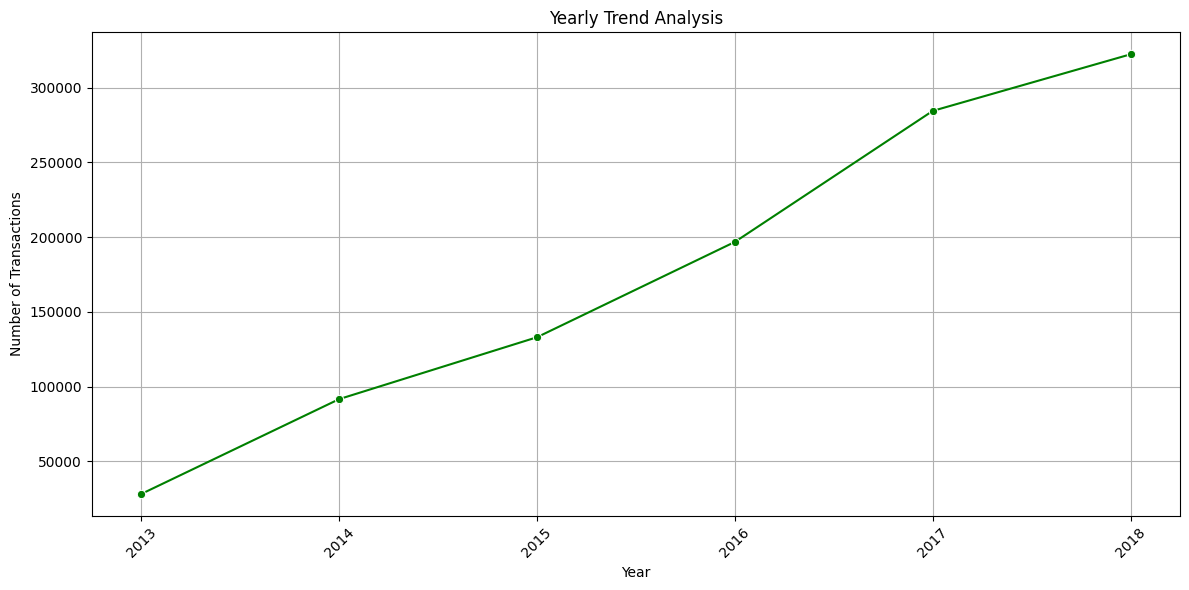

In [ ]:
# Create a 'month_year' column for monthly analysis
df_completed_trans_eda['month_year'] = df_completed_trans_eda['fulldate'].dt.to_period('M')

# Create a 'year' column for yearly analysis
df_completed_trans_eda['year'] = df_completed_trans_eda['fulldate'].dt.year

# Perform monthly trend analysis: aggregate data by 'month_year' for example, sum of transactions
monthly_trends = df_completed_trans_eda.groupby('month_year').size()  # Or use any other aggregate function, e.g., sum(), mean()

# Perform yearly trend analysis: aggregate data by 'year' for example, sum of transactions
yearly_trends = df_completed_trans_eda.groupby('year').size()  # Or use any other aggregate function, e.g., sum(), mean()

# Plot monthly trends
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_trends.index.astype(str), y=monthly_trends.values, marker='o', color='b')
plt.title('Monthly Trend Analysis')
plt.xlabel('Month-Year')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot yearly trends
plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_trends.index, y=yearly_trends.values, marker='o', color='g')
plt.title('Yearly Trend Analysis')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Convert 'fulldatewithtime' to datetime format (date and time)
df_completed_trans_eda['fulldatewithtime'] = pd.to_datetime(df_completed_trans_eda['fulldatewithtime'], errors='coerce')

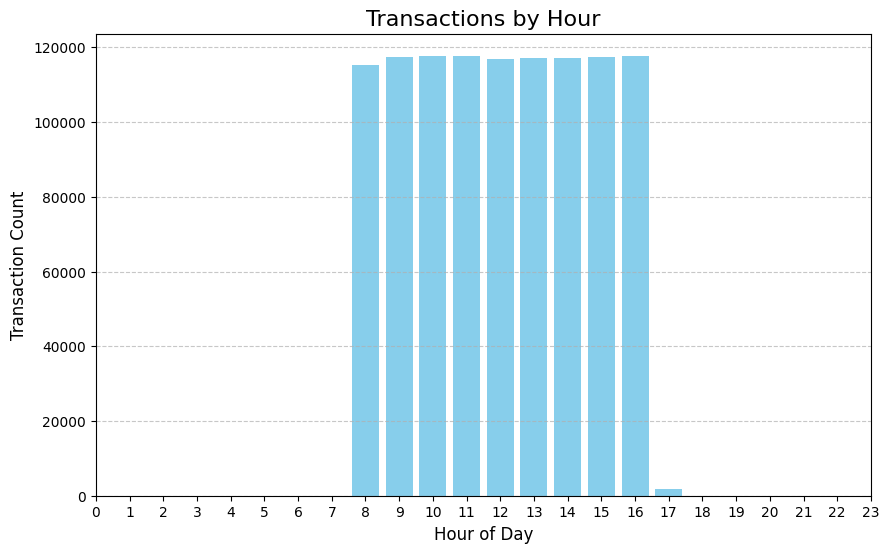

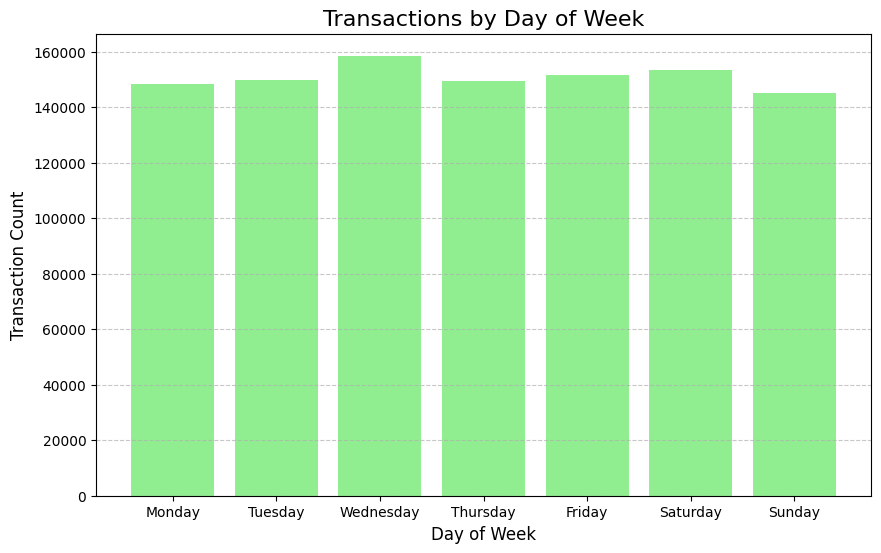

In [ ]:
# Extract time-based components
df_completed_trans_eda['hour'] = df_completed_trans_eda['fulldatewithtime'].dt.hour
df_completed_trans_eda['day_of_week'] = df_completed_trans_eda['fulldatewithtime'].dt.day_name()

# Group by hour to find peak transaction hours
hourly_transactions = (
    df_completed_trans_eda.groupby('hour').size().reset_index(name='transaction_count')
)

# Group by day of the week to find peak transaction days
daily_transactions = (
    df_completed_trans_eda.groupby('day_of_week').size().reset_index(name='transaction_count')
)

# Reorder days of the week for consistent visualization
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_transactions['day_of_week'] = pd.Categorical(daily_transactions['day_of_week'], categories=day_order, ordered=True)
daily_transactions = daily_transactions.sort_values('day_of_week')

# Plot hourly transactions
plt.figure(figsize=(10, 6))
plt.bar(hourly_transactions['hour'], hourly_transactions['transaction_count'], color='skyblue')
plt.title('Transactions by Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot daily transactions
plt.figure(figsize=(10, 6))
plt.bar(daily_transactions['day_of_week'], daily_transactions['transaction_count'], color='lightgreen')
plt.title('Transactions by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

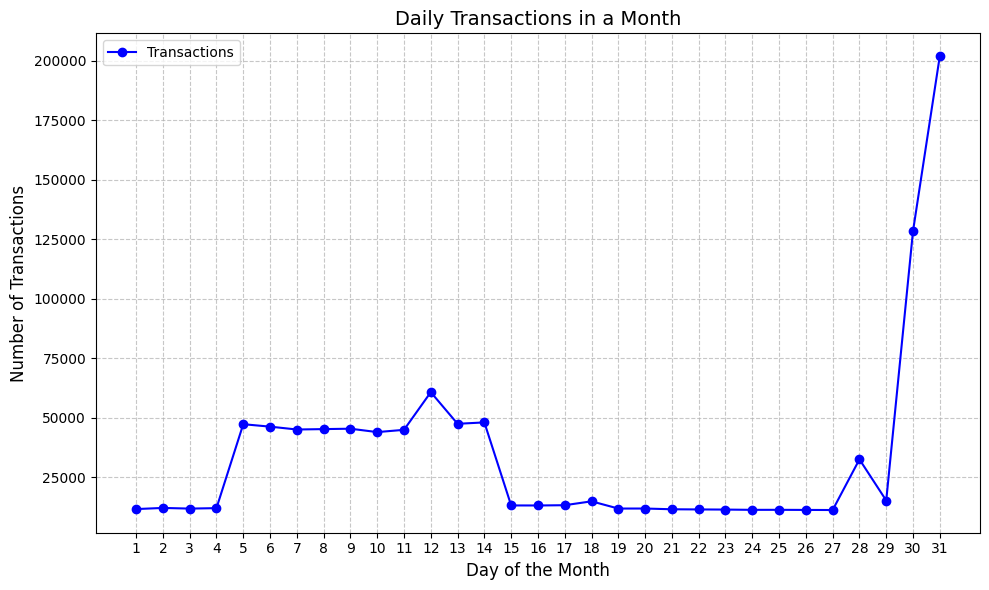

In [ ]:
# Assuming df_completed_trans is your DataFrame
# Grouping by 'day' and counting the number of transactions for each day
daily_transactions = df_completed_trans_eda.groupby('day').size().reset_index(name='transaction_count')

# Plotting the line graph
plt.figure(figsize=(10, 6))
plt.plot(daily_transactions['day'], daily_transactions['transaction_count'], marker='o', color='b', label='Transactions')

# Adding labels and title
plt.title('Daily Transactions in a Month', fontsize=14)
plt.xlabel('Day of the Month', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(range(1, 32))  # Assuming up to 31 days in a month
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

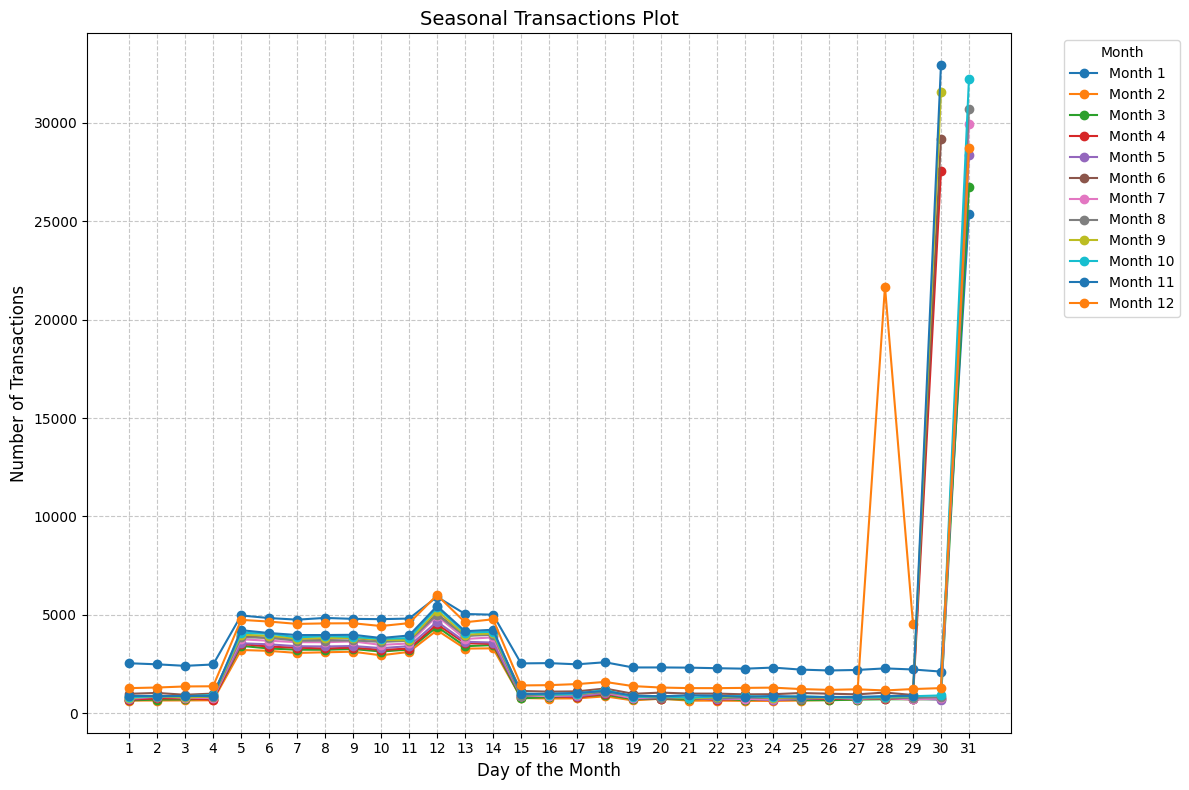

In [ ]:
# Group by 'month' and 'day' to count transactions
seasonal_data = df_completed_trans_eda.groupby(['month', 'day']).size().reset_index(name='transaction_count')

# Create a seasonal plot
plt.figure(figsize=(12, 8))
months = seasonal_data['month'].unique()

for month in months:
    monthly_data = seasonal_data[seasonal_data['month'] == month]
    plt.plot(
        monthly_data['day'],
        monthly_data['transaction_count'],
        marker='o',
        label=f'Month {month}'
    )

# Add labels, title, and legend
plt.title('Seasonal Transactions Plot', fontsize=14)
plt.xlabel('Day of the Month', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.xticks(range(1, 32))  # Assuming up to 31 days in a month
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
df_completed_trans_eda[['account_id','fulldate','fulltime','date','hour','day_of_week']]

,account_id,fulldate,fulltime,date,hour,day_of_week
0,A00002378,2013-01-01,11:02:40,2013-01-01,11,Tuesday
1,A00000576,2013-01-01,08:23:33,2013-01-01,8,Tuesday
2,A00000704,2013-01-01,15:19:21,2013-01-01,15,Tuesday
3,A00003818,2013-01-01,10:42:35,2013-01-01,10,Tuesday
4,A00001972,2013-01-02,11:39:25,2013-01-02,11,Wednesday
...,...,...,...,...,...,...
1056315,A00002906,2018-12-31,15:18:14,2018-12-31,15,Monday
1056316,A00002935,2018-12-31,13:05:00,2018-12-31,13,Monday
1056317,A00002869,2018-12-31,08:30:13,2018-12-31,8,Monday
1056318,A00002907,2018-12-31,14:45:19,2018-12-31,14,Monday


In [ ]:
df_completed_trans.to_csv('df_completed_trans.csv', index=False)

#Behavorial Segementation (based on transaction history)

In [ ]:
df_segmented_trans = df_completed_trans.copy()
df_segmented_trans = df_segmented_trans[df_segmented_trans['year'] == 2018]

Segmentation on customer behavior using last 12 month data

In [ ]:
# Group by 'account_id' and aggregate the necessary values
count_transaction = df_segmented_trans.groupby('account_id').agg(
    transaction_count=('trans_id', 'nunique'),
    average_balance=('balance', 'mean'),
    volume_credit=('amount', lambda x: x[df_segmented_trans['type'] == 'Credit'].sum()),
    volume_debit=('amount', lambda x: x[df_segmented_trans['type'] == 'Debit'].sum())
).reset_index()

# Display the resulting DataFrame
count_transaction

,account_id,transaction_count,average_balance,volume_credit,volume_debit
0,A00000001,62,15097.55,45415.30,46744.60
1,A00000002,85,40611.38,268232.30,279479.60
2,A00000003,92,28028.02,114919.30,90572.60
3,A00000004,69,22460.16,67780.70,53936.60
4,A00000005,66,25866.24,61534.10,61006.60
...,...,...,...,...,...
4487,A00011333,71,59156.52,196526.80,227167.60
4488,A00011349,88,38971.95,554453.90,548778.00
4489,A00011359,95,48043.31,356935.40,313924.60
4490,A00011362,117,34379.99,214487.10,203804.60


In [ ]:
file_path = "count_transaction.csv"
count_transaction.to_csv(file_path, index=False)

In [ ]:
customer_behaviour = count_transaction.copy()

### Merge DataFrame

Using outer/right join since we want to take customer who doesn't do transaction in year 2018. Reason: no account that doesn't have disposition id

In [ ]:
# Merge 'customer_behaviour' and 'disposition' on 'account_id'
trans_disp = pd.merge(customer_behaviour, df_completed_disposition, on='account_id', how='right')
trans_disp.head()

,account_id,transaction_count,average_balance,volume_credit,volume_debit,disp_id,client_id,type,client_id_new
0,A00000001,62.00,15097.55,45415.30,46744.60,D00000001,1,Owner,C00000001
1,A00000002,85.00,40611.38,268232.30,279479.60,D00000002,2,Owner,C00000002
2,A00000002,85.00,40611.38,268232.30,279479.60,D00000003,3,User,C00000003
3,A00000003,92.00,28028.02,114919.30,90572.60,D00000004,4,Owner,C00000004
4,A00000003,92.00,28028.02,114919.30,90572.60,D00000005,5,User,C00000005


Using outer/left join since we want collect customer wo doesn't have card, but have transaction in 2018

In [ ]:
# Merge 'trans_disp' and 'df_completed_card' on 'disp_id'
trans_disp_card = pd.merge(trans_disp, df_completed_card, on='disp_id', how='left')
trans_disp_card.head()

,account_id,transaction_count,average_balance,volume_credit,volume_debit,disp_id,client_id,type_x,client_id_new,card_id,type_y,year,month,day,fulldate,date
0,A00000001,62.00,15097.55,45415.30,46744.60,D00000001,1,Owner,C00000001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A00000002,85.00,40611.38,268232.30,279479.60,D00000002,2,Owner,C00000002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A00000002,85.00,40611.38,268232.30,279479.60,D00000003,3,User,C00000003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A00000003,92.00,28028.02,114919.30,90572.60,D00000004,4,Owner,C00000004,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A00000003,92.00,28028.02,114919.30,90572.60,D00000005,5,User,C00000005,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Using left/inner join cause we only want to extract client data which account have/don't have transaction in 2018

In [ ]:
# Merge 'trans_disp_card' and 'df_completed_client' on 'client_id_new' from 'trans_disp_card' and 'client_id' from 'df_completed_client'
trans_disp_card_client = pd.merge(trans_disp_card, df_completed_client, left_on='client_id_new', right_on='client_id', how='inner')
trans_disp_card_client.head()

,account_id,transaction_count,average_balance,volume_credit,volume_debit,disp_id,client_id_x,type_x,client_id_new,card_id,...,last,phone,email,address_1,address_2,city,state,zipcode,district_id,date_y
0,A00000001,62.00,15097.55,45415.30,46744.60,D00000001,1,Owner,C00000001,NaN,...,Smith,367-171-6840,emma.smith@gmail.com,387 Wellington Ave.,Unit 1,Albuquerque,NM,47246,18,1990-12-13
1,A00000002,85.00,40611.38,268232.30,279479.60,D00000002,2,Owner,C00000002,NaN,...,Thompson,212-423-7734,noah.thompson@gmail.com,75 W. Berkshire St.,Unknown,New York City,NY,10040,1,1965-02-04
2,A00000002,85.00,40611.38,268232.30,279479.60,D00000003,3,User,C00000003,NaN,...,Johnson,212-425-6932,olivia.johnson@outlook.com,36 Second St.,Unknown,New York City,NY,10162,1,1960-10-09
3,A00000003,92.00,28028.02,114919.30,90572.60,D00000004,4,Owner,C00000004,NaN,...,White,951-567-8925,liam.white@gmail.com,7607 Sunnyslope Street,Unknown,Indianapolis,IN,49047,5,1976-12-01
4,A00000003,92.00,28028.02,114919.30,90572.60,D00000005,5,User,C00000005,NaN,...,Williams,428-265-1568,sophia.williams@gmail.com,755 Galvin Street,Unknown,Indianapolis,IN,40852,5,1980-07-03


### Cleaning Data

In [ ]:
# Drop specified columns from 'trans_disp_card_client'
trans_disp_card_client = trans_disp_card_client.drop(
    columns=['disp_id', 'card_id', 'client_id_y', 'social', 'first',
              'middle', 'last', 'phone', 'email', 'address_1', 'address_2'])

Check what is duplicate data

In [ ]:
# Identify rows with duplicate 'account_id'
duplicates_account = trans_disp_card_client[trans_disp_card_client.duplicated(subset='account_id', keep=False)]

# Display the duplicate rows
duplicates_account

,account_id,transaction_count,average_balance,volume_credit,volume_debit,client_id_x,type_x,client_id_new,type_y,year_x,...,fulldate_y,day_y,month_y,year_y,age,city,state,zipcode,district_id,date_y
1,A00000002,85.00,40611.38,268232.30,279479.60,2,Owner,C00000002,NaN,NaN,...,1965-02-04,4,2,1965,54,New York City,NY,10040,1,1965-02-04
2,A00000002,85.00,40611.38,268232.30,279479.60,3,User,C00000003,NaN,NaN,...,1960-10-09,9,10,1960,59,New York City,NY,10162,1,1960-10-09
3,A00000003,92.00,28028.02,114919.30,90572.60,4,Owner,C00000004,NaN,NaN,...,1976-12-01,1,12,1976,43,Indianapolis,IN,49047,5,1976-12-01
4,A00000003,92.00,28028.02,114919.30,90572.60,5,User,C00000005,NaN,NaN,...,1980-07-03,3,7,1980,39,Indianapolis,IN,40852,5,1980-07-03
9,A00000008,85.00,45820.67,278777.30,255548.60,10,Owner,C00000010,NaN,NaN,...,1963-05-01,1,5,1963,56,New Bedford,MA,2740,57,1963-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5346,A00011111,102.00,82794.44,663414.80,606561.60,13658,User,C00013658,NaN,NaN,...,1977-04-23,23,4,1977,42,Quincy,MA,2170,59,1977-04-23
5351,A00011186,90.00,81243.86,550422.10,543175.00,13750,Owner,C00013750,VISA Standard,2018.00,...,2000-11-13,13,11,2000,19,Portland,OR,49151,12,2000-11-13
5352,A00011186,90.00,81243.86,550422.10,543175.00,13751,User,C00013751,NaN,NaN,...,1999-07-20,20,7,1999,20,Portland,OR,41492,12,1999-07-20
5364,A00011349,88.00,38971.95,554453.90,548778.00,13955,Owner,C00013955,NaN,NaN,...,1965-10-30,30,10,1965,54,New York City,NY,10121,1,1965-10-30


In [ ]:
# Sort the DataFrame by 'type_x' so that 'Owner' comes first
trans_disp_card_client = trans_disp_card_client.sort_values(by='type_x', ascending=False)

# Drop duplicate 'account_id', keeping the first occurrence (prioritizing 'Owner')
trans_disp_card_client = trans_disp_card_client.drop_duplicates(subset='account_id', keep='first')

# Display the resulting DataFrame
trans_disp_card_client

,account_id,transaction_count,average_balance,volume_credit,volume_debit,client_id_x,type_x,client_id_new,type_y,year_x,...,fulldate_y,day_y,month_y,year_y,age,city,state,zipcode,district_id,date_y
1465,A00001280,55.00,43436.99,63679.80,44262.60,1549,User,C00001549,NaN,NaN,...,1948-11-14,14,11,1948,71,Los Angeles,CA,41574,70,1948-11-14
3523,A00003076,56.00,21093.55,51036.70,44680.60,3720,User,C00003720,NaN,NaN,...,1956-12-07,7,12,1956,63,Houston,TX,45355,54,1956-12-07
982,A00000859,104.00,30030.69,146124.20,143105.60,1036,User,C00001036,NaN,NaN,...,1996-12-06,6,12,1996,23,Oklahoma City,OK,43836,13,1996-12-06
3530,A00003083,58.00,44364.57,299246.20,286880.60,3729,User,C00003729,NaN,NaN,...,1961-08-22,22,8,1961,58,Warwick,RI,42659,66,1961-08-22
979,A00000857,57.00,22853.29,55452.40,58868.60,1033,User,C00001033,NaN,NaN,...,1957-10-14,14,10,1957,62,New York City,NY,10118,1,1957-10-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,A00001710,68.00,37028.93,84525.40,68072.60,2075,Owner,C00002075,NaN,NaN,...,1942-01-29,29,1,1942,78,Chicago,IL,44548,74,1942-01-29
1959,A00001709,73.00,59379.83,238275.40,220684.60,2074,Owner,C00002074,VISA Signature,2017.00,...,1981-09-16,16,9,1981,38,New Orleans,LA,44168,24,1981-09-16
1958,A00001708,74.00,28701.40,188894.30,192456.60,2073,Owner,C00002073,NaN,NaN,...,1976-02-08,8,2,1976,43,Virginia Beach,VA,43756,22,1976-02-08
1957,A00001707,54.00,14203.74,156205.20,141420.60,2072,Owner,C00002072,NaN,NaN,...,1964-02-09,9,2,1964,55,Rochester,NY,14620,75,1964-02-09


In [ ]:
# Fill missing values in 'type_y' with 'No Card'
trans_disp_card_client['type_y'] = trans_disp_card_client['type_y'].fillna('No Card')

# Fill mising value 'transaction_count' with 0
trans_disp_card_client['transaction_count'] = trans_disp_card_client['transaction_count'].fillna(0)
trans_disp_card_client['average_balance'] = trans_disp_card_client['average_balance'].fillna(0)
trans_disp_card_client['volume_debit'] = trans_disp_card_client['volume_debit'].fillna(0)
trans_disp_card_client['volume_credit'] = trans_disp_card_client['volume_credit'].fillna(0)

### Feature Scalling

In [ ]:
# Standart Saler
from sklearn.preprocessing import StandardScaler

numerical_columns_trans_segmentation = ['transaction_count', 'average_balance',
                                        'volume_debit', 'volume_credit', 'age']

scaler_trans = StandardScaler()
df_scaled_trans = scaler_trans.fit_transform(trans_disp_card_client[numerical_columns_trans_segmentation])


In [ ]:
# MinMax Scaler
from sklearn.preprocessing import MinMaxScaler

numerical_columns_trans_segmentation = ['transaction_count', 'average_balance',
                                        'volume_debit', 'volume_credit', 'age']

scaler_trans = MinMaxScaler()
df_scaled_trans = scaler.fit_transform(trans_disp_card_client[numerical_columns_trans_segmentation])


### K-Means Intial Approach

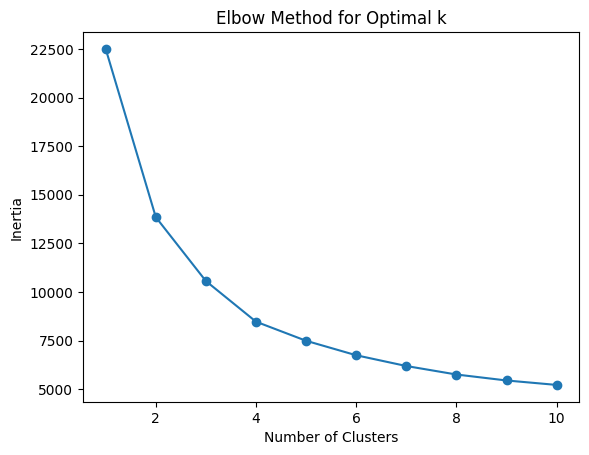

In [ ]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled_trans)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

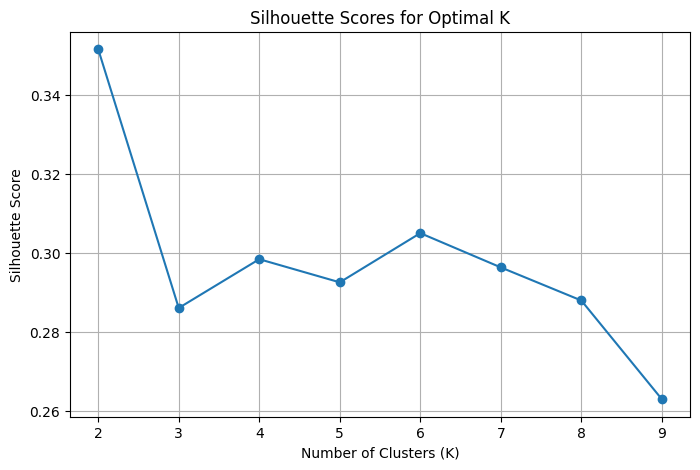

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 10): # Silhouette requires at least two clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled_trans)
    sil_scores.append(silhouette_score(df_scaled_trans, kmeans.labels_))

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), sil_scores, marker='o')
plt.title('Silhouette Scores for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

###Clustering

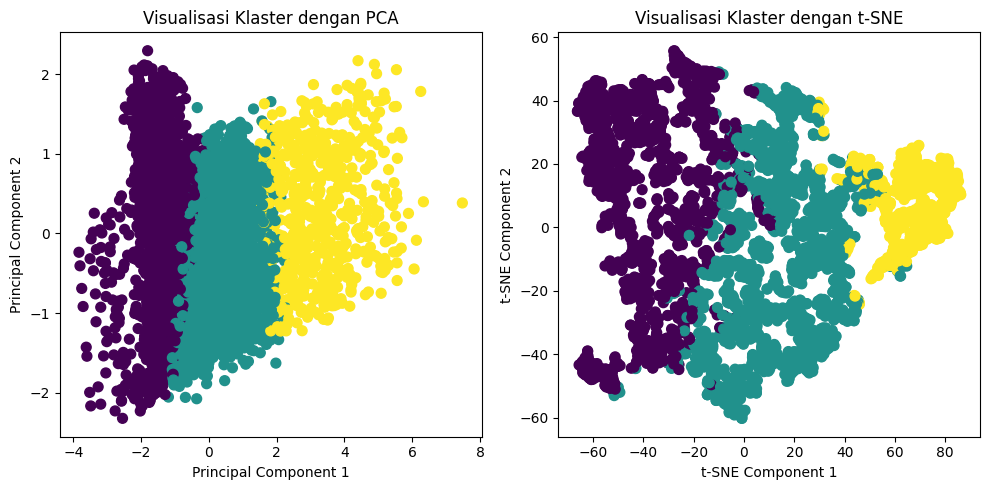

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 2. Clustering dengan KMeans
# Menentukan jumlah klaster optimal (dari elbow method sebelumnya)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled_trans)

# 3. Visualisasi PCA
pca = PCA(n_components=2) # Reduksi ke 2 dimensi
X_pca = pca.fit_transform(df_scaled_trans)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Visualisasi Klaster dengan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 4. Visualisasi t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_scaled_trans)

plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', s=50)
plt.title('Visualisasi Klaster dengan t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

plt.tight_layout()
plt.show()

In [ ]:
# Perform KMeans clustering (replace 3 with your optimal k)
kmeans = KMeans(n_clusters=3, random_state=42) # Example with 3 clusters
kmeans.fit(df_scaled_trans)

# Assign the cluster labels to the DataFrame
trans_disp_card_client['Cluster'] = kmeans.labels_

# Create a 3D scatter plot using Plotly
fig = px.scatter_3d(
      trans_disp_card_client,
      x='transaction_count', # Replace with your actual column names
      y='average_balance', # Replace with your actual column names
      z='volume_credit', # Replace with your actual column names
      color='Cluster', # Cluster column as the color
      color_continuous_scale='YlGnBu',
      title='3D Scatter Plot of Loan Segments'
)

# Show the plot
fig.show()

In [ ]:
# Let's try to do grouping by the cluster created
trans_disp_card_client.groupby('Cluster').agg({
    'transaction_count' : 'mean',
    'average_balance' : 'mean',
    'volume_debit' : 'mean',
    'volume_credit' : 'mean',
    'age' : 'mean',
})

,transaction_count,average_balance,volume_debit,volume_credit,age
Cluster,,,,,
0,59.86,23781.73,76666.47,78379.34,54.40
1,76.54,44893.77,218252.22,225407.97,38.20
2,90.90,64790.60,572511.46,587964.11,41.10


In [ ]:
trans_disp_card_client.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4500 entries, 1465 to 5368
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   account_id         4500 non-null   object        
 1   transaction_count  4500 non-null   float64       
 2   average_balance    4500 non-null   float64       
 3   volume_credit      4500 non-null   float64       
 4   volume_debit       4500 non-null   float64       
 5   client_id_x        4500 non-null   int64         
 6   type_x             4500 non-null   object        
 7   client_id_new      4500 non-null   object        
 8   type_y             4500 non-null   object        
 9   year_x             741 non-null    float64       
 10  month_x            741 non-null    float64       
 11  day_x              741 non-null    float64       
 12  fulldate_x         741 non-null    object        
 13  date_x             741 non-null    object        
 14  sex       

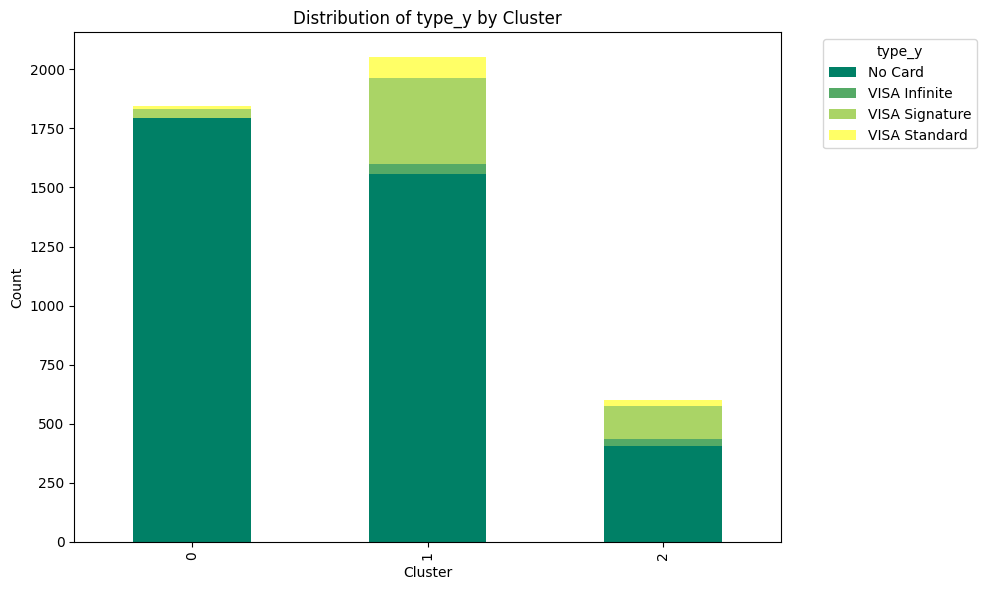

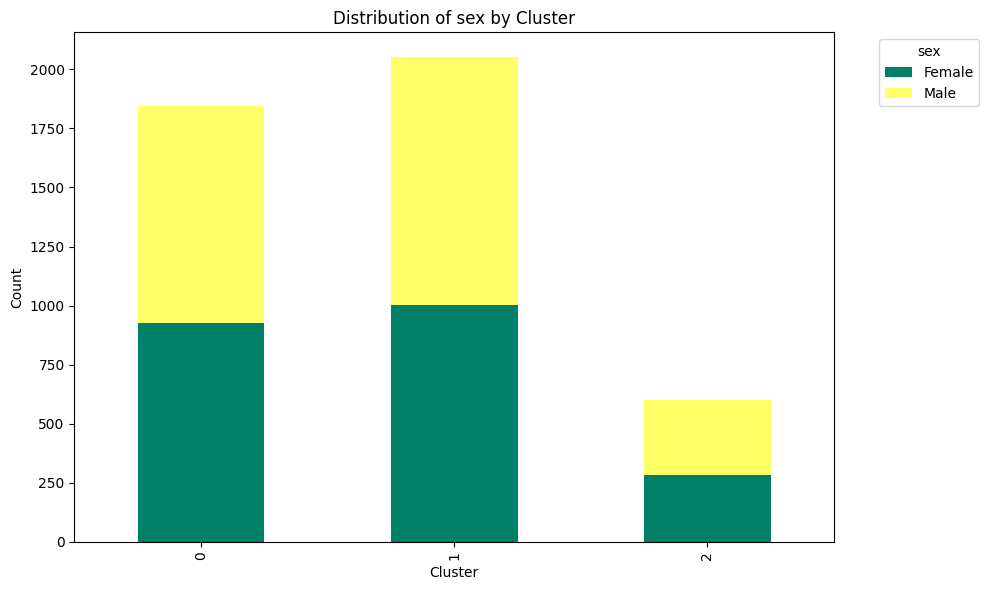

<ipython-input-130-60eb12dd3aa1>:19: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



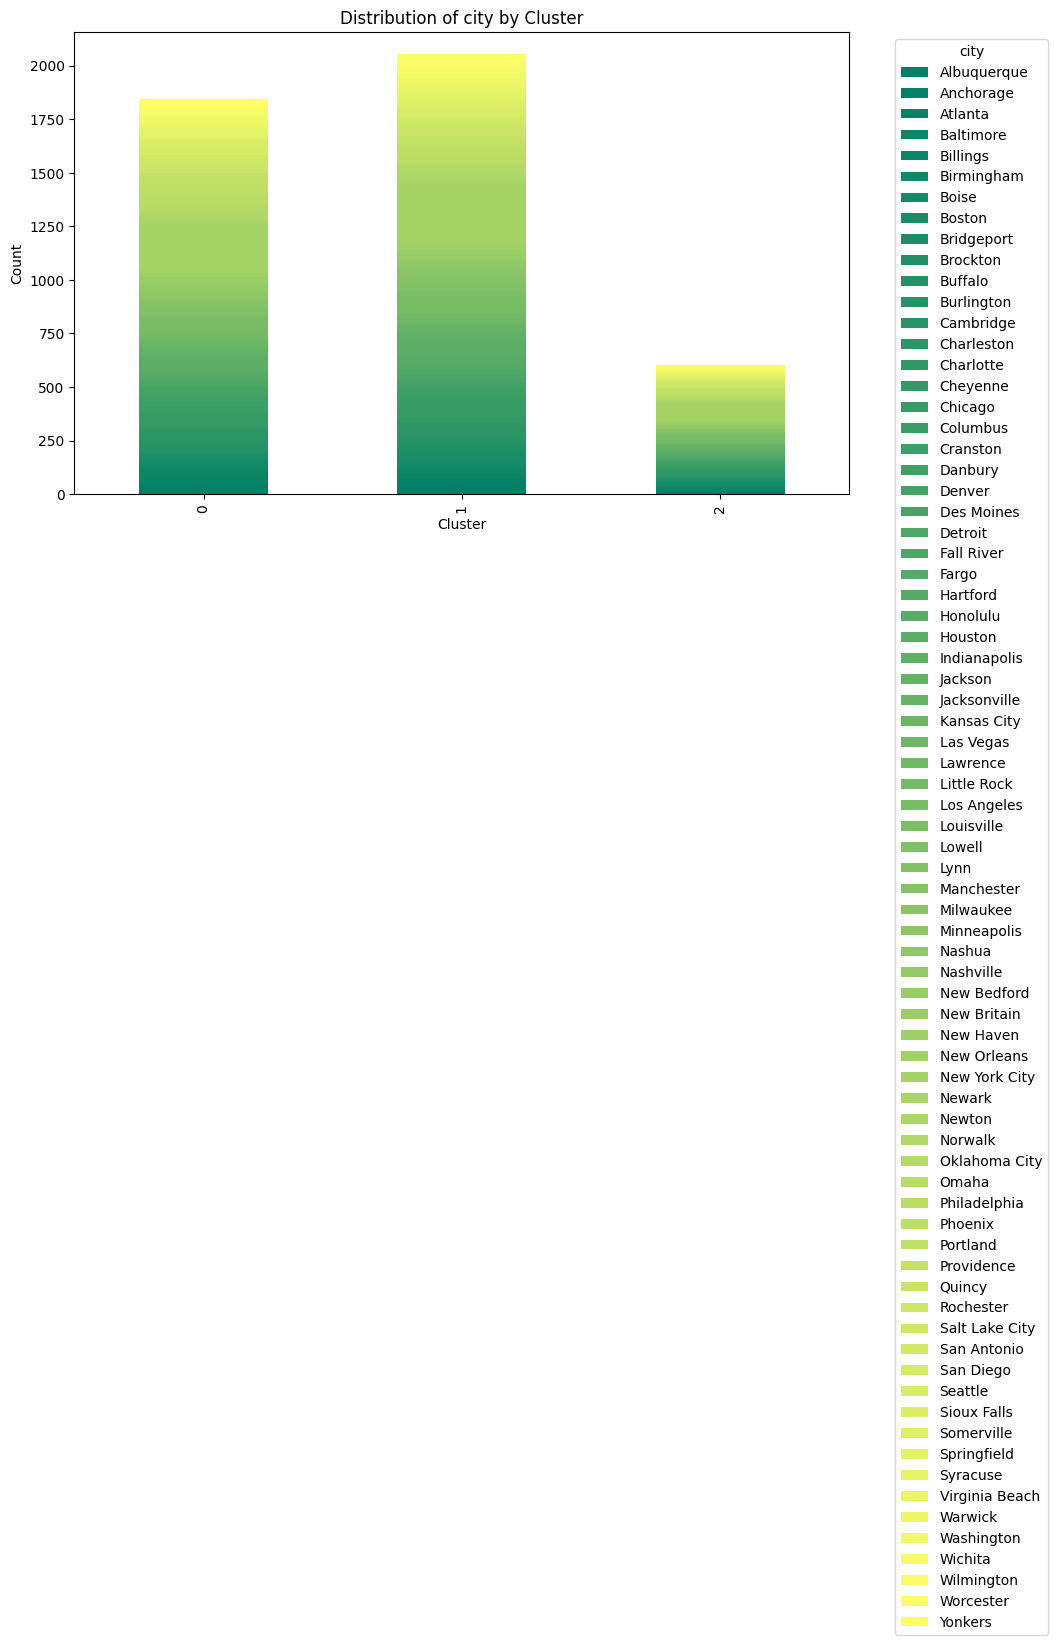

In [ ]:
# List of categorical columns
categorical_columns = ['type_y','sex', 'city']

# Loop through each categorical column
for col in categorical_columns:
    plt.figure(figsize=(10, 6)) # Set figure size

    # Cross-tabulation for counts by cluster
    cluster_counts = pd.crosstab(trans_disp_card_client['Cluster'], trans_disp_card_client[col])

    # Plot as a stacked bar chart
    cluster_counts.plot(kind='bar', stacked=True, colormap='summer', ax=plt.gca())

    # Customize the plot
    plt.title(f'Distribution of {col} by Cluster')
    plt.ylabel('Count')
    plt.xlabel('Cluster')
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout() # Adjust layout to fit the legend

    # Show the chart
    plt.show()

#Segmentation Loan X Transaction

### Merge Dataframe

In [ ]:
df_loan_trans = df_completed_trans.copy()

In [ ]:
# Group by 'account_id' and aggregate the necessary values
finance_transactions = df_loan_trans.groupby('account_id').agg(
    transaction_count=('trans_id', 'nunique'),
    average_balance=('balance', 'mean'),
    first_trans=('fulldate', 'min'),
    volume_credit=('amount', lambda x: x[df_loan_trans['type'] == 'Credit'].sum()),
    volume_debit=('amount', lambda x: x[df_loan_trans['type'] == 'Debit'].sum())
).reset_index()

# Display the resulting DataFrame
finance_transactions

KeyboardInterrupt: 

In [ ]:
import gdown
import pandas as pd

# File ID dari tautan Google Drive
file_id = "1I_fG9bo1T5lPa0pnkbZaFhAr3AUbxTrR"

# URL untuk mengunduh file
url = f"https://drive.google.com/uc?id={file_id}"

# Nama file output
output_file = "data.csv"

# Unduh file dari Google Drive
gdown.download(url, output_file, quiet=False)

# Baca file CSV menggunakan pandas
finance_transactions = pd.read_csv(output_file)

Downloading...
From: https://drive.google.com/uc?id=1I_fG9bo1T5lPa0pnkbZaFhAr3AUbxTrR
To: /content/data.csv
100%|██████████| 306k/306k [00:00<00:00, 46.1MB/s]


In [ ]:
finance_transactions.to_csv('finance_transactions.csv', index=False)

In [ ]:
history_trans = finance_transactions.copy()

In [ ]:
# Merge 'count_transaction' and 'disposition' on 'account_id'
trans_loan_outer = pd.merge(history_trans, df_loan_segmentation, on='account_id', how='outer')
trans_loan_outer.head()

,account_id,transaction_count,average_balance,first_trans,volume_credit,volume_debit,loan_id,amount,duration,payments,...,year,month,day,fulldate,location,purpose,date,status_label,year_month,loan_status_flag
0,A00000001,239,15994.01,2015-03-24,194320.50,180854.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaN
1,A00000002,478,36540.70,2013-02-26,1597053.50,1554425.80,4959.00,80952.00,24.00,3373.00,...,2014.00,1.00,5.00,2014-01-05,1,home,2014-01-05,Active,2014-01,3
2,A00000003,117,26973.51,2017-07-07,173059.00,121962.80,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaN
3,A00000004,186,21753.45,2016-02-21,192346.00,158625.40,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaN
4,A00000005,84,25090.07,2017-05-30,97485.00,69396.40,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaN


In [ ]:
# Merge 'customer_behaviour' and 'disposition' on 'account_id'
trans_loan_disp = pd.merge(trans_loan_outer, df_completed_disposition, on='account_id', how='inner')
trans_loan_disp.head()

,account_id,transaction_count,average_balance,first_trans,volume_credit,volume_debit,loan_id,amount,duration,payments,...,location,purpose,date,status_label,year_month,loan_status_flag,disp_id,client_id,type,client_id_new
0,A00000001,239,15994.01,2015-03-24,194320.50,180854.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,D00000001,1,Owner,C00000001
1,A00000002,478,36540.70,2013-02-26,1597053.50,1554425.80,4959.00,80952.00,24.00,3373.00,...,1,home,2014-01-05,Active,2014-01,3,D00000002,2,Owner,C00000002
2,A00000002,478,36540.70,2013-02-26,1597053.50,1554425.80,4959.00,80952.00,24.00,3373.00,...,1,home,2014-01-05,Active,2014-01,3,D00000003,3,User,C00000003
3,A00000003,117,26973.51,2017-07-07,173059.00,121962.80,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,D00000004,4,Owner,C00000004
4,A00000003,117,26973.51,2017-07-07,173059.00,121962.80,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,D00000005,5,User,C00000005


In [ ]:
# Merge 'trans_disp_card' and 'df_completed_client' on 'client_id_new' from 'trans_disp_card' and 'client_id' from 'df_completed_client'
trans_loan_disp_client = pd.merge(trans_loan_disp, df_completed_client, left_on='client_id_new', right_on='client_id', how='inner')
trans_loan_disp_client.head()

,account_id,transaction_count,average_balance,first_trans,volume_credit,volume_debit,loan_id,amount,duration,payments,...,last,phone,email,address_1,address_2,city,state,zipcode,district_id,date_y
0,A00000001,239,15994.01,2015-03-24,194320.50,180854.00,NaN,NaN,NaN,NaN,...,Smith,367-171-6840,emma.smith@gmail.com,387 Wellington Ave.,Unit 1,Albuquerque,NM,47246,18,1990-12-13
1,A00000002,478,36540.70,2013-02-26,1597053.50,1554425.80,4959.00,80952.00,24.00,3373.00,...,Thompson,212-423-7734,noah.thompson@gmail.com,75 W. Berkshire St.,Unknown,New York City,NY,10040,1,1965-02-04
2,A00000002,478,36540.70,2013-02-26,1597053.50,1554425.80,4959.00,80952.00,24.00,3373.00,...,Johnson,212-425-6932,olivia.johnson@outlook.com,36 Second St.,Unknown,New York City,NY,10162,1,1960-10-09
3,A00000003,117,26973.51,2017-07-07,173059.00,121962.80,NaN,NaN,NaN,NaN,...,White,951-567-8925,liam.white@gmail.com,7607 Sunnyslope Street,Unknown,Indianapolis,IN,49047,5,1976-12-01
4,A00000003,117,26973.51,2017-07-07,173059.00,121962.80,NaN,NaN,NaN,NaN,...,Williams,428-265-1568,sophia.williams@gmail.com,755 Galvin Street,Unknown,Indianapolis,IN,40852,5,1980-07-03


In [ ]:
print(trans_loan_disp_client.dtypes)

account_id                   object
transaction_count             int64
average_balance             float64
first_trans                  object
volume_credit               float64
volume_debit                float64
loan_id                     float64
amount                      float64
duration                    float64
payments                    float64
status                     category
year_x                      float64
month_x                     float64
day_x                       float64
fulldate_x           datetime64[ns]
location                   category
purpose                    category
date_x                       object
status_label               category
year_month                period[M]
loan_status_flag           category
disp_id                      object
client_id_x                   int64
type                         object
client_id_new                object
client_id_y                  object
sex                          object
fulldate_y           datetim

In [ ]:
credit_score_all = trans_loan_disp_client.copy()

### Cleaning Data

In [ ]:
#Drop specified columns from 'credit_score_all'
credit_score_all = credit_score_all.drop(
    columns=['purpose', 'date_x', 'year_x', 'month_x', 'day_x', 'status', 'location',
             'year_month', 'disp_id', 'client_id_x','client_id_new', 'client_id_y',
             'fulldate_y', 'day_y', 'month_y', 'year_y', 'social', 'first', 'middle',
             'last', 'phone', 'email', 'address_1', 'address_2', 'zipcode', 'district_id', 'date_y',])

In [ ]:
print(credit_score_all.dtypes)

account_id                   object
transaction_count             int64
average_balance             float64
first_trans                  object
volume_credit               float64
volume_debit                float64
loan_id                     float64
amount                      float64
duration                    float64
payments                    float64
fulldate_x           datetime64[ns]
status_label               category
loan_status_flag           category
type                         object
sex                          object
age                           int64
city                         object
state                        object
dtype: object


In [ ]:
# Sort the DataFrame by 'type_x' so that 'Owner' comes first
credit_score_all = credit_score_all.sort_values(by='type', ascending=False)

# Drop duplicate 'account_id', keeping the first occurrence (prioritizing 'Owner')
credit_score_all = credit_score_all.drop_duplicates(subset='account_id', keep='first')

# Display the resulting DataFrame
credit_score_all

,account_id,transaction_count,average_balance,first_trans,volume_credit,volume_debit,loan_id,amount,duration,payments,fulldate_x,status_label,loan_status_flag,type,sex,age,city,state
1465,A00001280,207,29148.43,2015-05-03,231156.20,175488.40,NaN,NaN,NaN,NaN,NaT,NaN,NaN,User,Female,71,Los Angeles,CA
3523,A00003076,317,18695.13,2013-03-27,293185.90,264824.40,NaN,NaN,NaN,NaN,NaT,NaN,NaN,User,Female,63,Houston,TX
982,A00000859,117,29817.80,2017-08-26,204331.00,163705.60,NaN,NaN,NaN,NaN,NaT,NaN,NaN,User,Male,23,Oklahoma City,OK
3530,A00003083,93,44849.99,2017-03-18,529459.00,468433.60,NaN,NaN,NaN,NaN,NaT,NaN,NaN,User,Female,58,Warwick,RI
979,A00000857,283,19422.09,2013-09-16,291030.30,269287.80,NaN,NaN,NaN,NaN,NaT,NaN,NaN,User,Male,62,New York City,NY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,A00001710,89,34906.87,2017-05-25,134054.10,84108.40,NaN,NaN,NaN,NaN,NaT,NaN,NaN,Owner,Male,78,Chicago,IL
1959,A00001709,180,52713.30,2016-04-23,644080.40,568603.20,NaN,NaN,NaN,NaN,NaT,NaN,NaN,Owner,Female,38,New Orleans,LA
1958,A00001708,299,28289.96,2014-11-21,778776.30,748952.40,NaN,NaN,NaN,NaN,NaT,NaN,NaN,Owner,Male,43,Virginia Beach,VA
1957,A00001707,105,16539.04,2017-01-13,307207.30,284132.80,NaN,NaN,NaN,NaN,NaT,NaN,NaN,Owner,Female,55,Rochester,NY


In [ ]:
print(credit_score_all.dtypes)

account_id                   object
transaction_count             int64
average_balance             float64
first_trans                  object
volume_credit               float64
volume_debit                float64
loan_id                     float64
amount                      float64
duration                    float64
payments                    float64
fulldate_x           datetime64[ns]
status_label               category
loan_status_flag           category
type                         object
sex                          object
age                           int64
city                         object
state                        object
dtype: object


In [ ]:
# Fill mising value 'transaction_count' with 0
credit_score_all['amount'] = credit_score_all['amount'].fillna(0)

In [ ]:
credit_score_no_loan = credit_score_all.copy()
# Delete rows where loan_id is not null
credit_score_no_loan = credit_score_no_loan[credit_score_no_loan['loan_id'].isnull()]

In [ ]:
credit_score_loan = credit_score_all.copy()
# Delete rows where loan_id is null
credit_score_loan = credit_score_loan[credit_score_loan['loan_id'].notnull()]

###Credit score

#### Credit Score Loan

In [ ]:
# Update loan_status_flag mapping
loan_status_mapping = {
    0: 0,  # Default remains 0
    2: 3,  # Complete changes from 2 to 3
    1: 1,  # Behind remains 1
    3: 2   # Active changes from 3 to 2
}

# Apply the mapping to loan_status_flag
credit_score_all['loan_status_flag'] = credit_score_all['loan_status_flag'].replace(loan_status_mapping)

# Example DataFrame
# Assuming 'credit_score_all' is already loaded as a pandas DataFrame.

# Normalize numerical features
scaler = MinMaxScaler()

credit_score_loan['normalized_balance'] = scaler.fit_transform(credit_score_loan[['average_balance']])
credit_score_loan['normalized_volume_credit'] = scaler.fit_transform(credit_score_loan[['volume_credit']])
credit_score_loan['normalized_volume_debit'] = scaler.fit_transform(credit_score_loan[['volume_debit']])
credit_score_loan['normalized_amount'] = scaler.fit_transform(credit_score_loan[['amount']])
credit_score_loan['normalized_duration'] = scaler.fit_transform(credit_score_loan[['duration']])

# Define a scoring function
def calculate_credit_score(row):
    # Weight features for the credit score calculation
    loan_status_weight = 0.4  # Loan status flag has high impact
    balance_weight = 0.2      # Average balance has medium impact
    credit_weight = 0.2       # Volume of credit transactions
    debit_weight = 0.1        # Volume of debit transactions
    amount_weight = 0.1       # Loan amount
    duration_weight = 0.1     # Duration

    # Calculate feature contributions
    loan_status_score = (4 - row['loan_status_flag']) / 4  # Normalize: 3 -> 0.25, ..., 0 -> 1
    balance_score = row['normalized_balance']
    credit_score = row['normalized_volume_credit']
    debit_score = row['normalized_volume_debit']
    amount_score = row['normalized_amount']
    duration_score = row['normalized_duration']

    # Weighted sum of scores
    total_score = (
        loan_status_score * loan_status_weight +
        balance_score * balance_weight +
        credit_score * credit_weight +
        debit_score * debit_weight +
        amount_score * amount_weight
    )

    # Map score to 300-850 range
    credit_score = (1 - total_score) * (850 - 300) + 300
    return credit_score

# Apply the scoring function to the DataFrame
credit_score_loan['credit_score'] = credit_score_loan.apply(calculate_credit_score, axis=1)

In [ ]:
credit_score_loan.to_csv('credit_score_loan.csv', index=False)

In [ ]:
credit_score_loan[['account_id', 'credit_score','status_label']]

,account_id,credit_score,status_label
4611,A00004144,615.38,Complete
896,A00000789,706.39,Complete
3494,A00003050,576.37,Active
3599,A00003143,672.27,Complete
4452,A00003906,593.28,Complete
...,...,...,...
2146,A00001869,612.29,Complete
1895,A00001656,655.68,Complete
2019,A00001762,682.34,Active
1948,A00001698,638.81,Complete


#### Credit Score No Loan

In [ ]:
# Normalize transactional data
scaler = MinMaxScaler()

credit_score_no_loan['normalized_balance'] = scaler.fit_transform(credit_score_no_loan[['average_balance']])
credit_score_no_loan['normalized_volume_credit'] = scaler.fit_transform(credit_score_no_loan[['volume_credit']])
credit_score_no_loan['normalized_volume_debit'] = scaler.fit_transform(credit_score_no_loan[['volume_debit']])
credit_score_no_loan['normalized_transaction_count'] = scaler.fit_transform(credit_score_no_loan[['transaction_count']])

# Define scoring function for non-loan customers
def calculate_transaction_score(row):
    # Assign weights to transactional features
    balance_weight = 0.4      # Balance is a major factor
    credit_weight = 0.3       # Credit transactions are important
    debit_weight = 0.2        # Debit transactions contribute less
    transaction_count_weight = 0.1  # Activity frequency has smaller weight

    # Weighted sum of scores
    total_score = (
        row['normalized_balance'] * balance_weight +
        row['normalized_volume_credit'] * credit_weight +
        row['normalized_volume_debit'] * debit_weight +
        row['normalized_transaction_count'] * transaction_count_weight
    )

    # Map the score to 300-850 range
    credit_score = (1 - total_score) * (850 - 300) + 300
    return credit_score

# Apply the scoring function
credit_score_no_loan['credit_score'] = credit_score_no_loan.apply(calculate_transaction_score, axis=1)

In [ ]:
# Combine the data frames
combined_credit_score = pd.concat([credit_score_loan, credit_score_no_loan], ignore_index=True)

In [ ]:
# Add "No Loan" to the existing categories
combined_credit_score['status_label'] = combined_credit_score['status_label'].cat.add_categories('No Loan')

# Fill missing values with "No Loan"
combined_credit_score['status_label'] = combined_credit_score['status_label'].fillna('No Loan')


#### Credit Score Logistic Regression

In [ ]:
# Filter hanya nasabah aktif
active_customers = credit_score_loan[credit_score_loan['status_label'].isin(['Active', 'Behind', 'Default'])]

# Buat kolom target berdasarkan status historis
credit_score_loan['is_default'] = credit_score_loan['status_label'].apply(lambda x: 1 if x == 'Default' else 0)

# Fitur untuk prediksi
features = ['credit_score']  # Menggunakan credit_score saja
X = active_customers[features]
y = active_customers['is_default']


In [ ]:
from sklearn.model_selection import train_test_split

# Split data ke dalam train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Buat dan latih model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi model
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      1.00      0.96        50
           1       1.00      0.33      0.50         6

    accuracy                           0.93        56
   macro avg       0.96      0.67      0.73        56
weighted avg       0.93      0.93      0.91        56



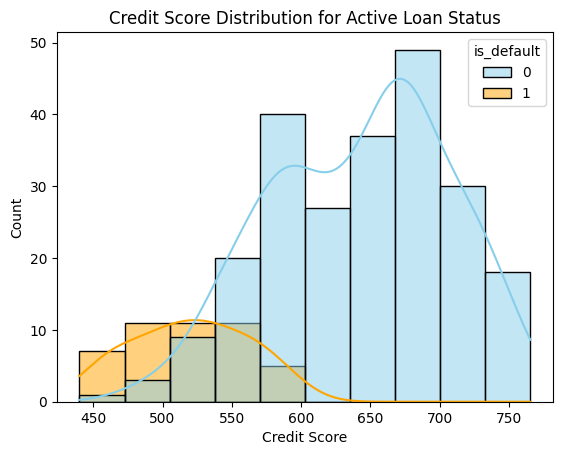

In [ ]:
# Membuat histogram dengan warna kustom
sns.histplot(
    active_customers,
    x='credit_score',
    hue='is_default',
    kde=True,
    palette={0: "skyblue", 1: "orange"}
)

# Menambahkan judul dan mengubah label sumbu x
plt.title('Credit Score Distribution for Active Loan Status')
plt.xlabel('Credit Score')  # Mengganti label sumbu x
plt.show()


#### XG Boast using SMOTE

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Pisahkan data historis (Completed dan Default) dan data aktif (Active dan Behind)
df_historical = credit_score_loan[credit_score_loan['status_label'].isin(['Complete', 'Default'])]
df_active = credit_score_loan[credit_score_loan['status_label'].isin(['Active', 'Behind'])]

# Siapkan fitur dan target untuk data historis
X = df_historical.drop(columns=['account_id', 'first_trans', 'fulldate_x', 'status_label', 'loan_status_flag', 'type', 'sex', 'city', 'state'])
y = df_historical['status_label'].apply(lambda x: 1 if x == 'Default' else 0)  # 1 = Default, 0 = Completed

# Handle class imbalance dengan SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split data historis menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Latih model XGBoost
model = XGBClassifier(scale_pos_weight=(y == 0).sum() / (y == 1).sum(), random_state=42)
model.fit(X_train, y_train)

# Evaluasi model pada data test
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Prediksi untuk data aktif
X_active = df_active.drop(columns=['account_id', 'first_trans', 'fulldate_x', 'status_label', 'loan_status_flag', 'type', 'sex', 'city', 'state'])
df_active['predicted_default_prob'] = model.predict_proba(X_active)[:, 1]  # Probabilitas default
df_active['predicted_status'] = df_active['predicted_default_prob'].apply(lambda x: 'Rawan Default' if x >= 0.5 else 'Aman')

# Tampilkan hasil prediksi
print(df_active[['account_id', 'predicted_default_prob', 'predicted_status']].head())

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        90
           1       0.97      1.00      0.99        72

    accuracy                           0.99       162
   macro avg       0.99      0.99      0.99       162
weighted avg       0.99      0.99      0.99       162

Confusion Matrix:
[[88  2]
 [ 0 72]]
     account_id  predicted_default_prob predicted_status
3494  A00003050                    0.00             Aman
4811  A00005228                    0.00             Aman
4769  A00004825                    0.00             Aman
4771  A00004851                    0.00             Aman
2510  A00002187                    0.00             Aman


<ipython-input-216-1fff3e9a6ecf>:35: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

<ipython-input-216-1fff3e9a6ecf>:36: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



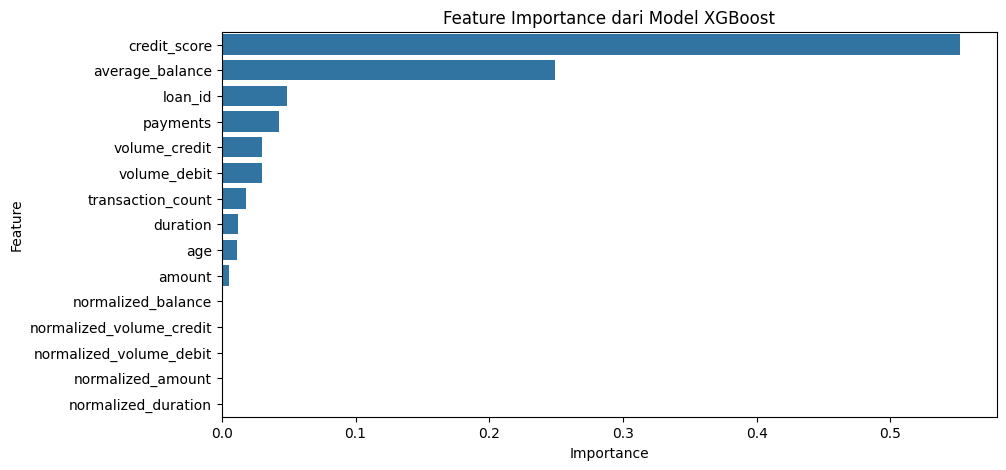

In [ ]:
# Dapatkan feature importance dari model XGBoost
feature_importance = model.feature_importances_
feature_names = X.columns

# Buat dataframe untuk visualisasi
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi feature importance
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance dari Model XGBoost')
plt.show()


In [ ]:
# Hitung jumlah nasabah "Behind" dan "Active" yang diprediksi akan default
predicted_default_counts = df_active[df_active['predicted_status'] == 'Rawan Default']['status_label'].value_counts()
print(predicted_default_counts)

status_label
Behind      19
Active       0
Complete     0
Default      0
Name: count, dtype: int64


In [ ]:
total_predicted_default = df_active[df_active['predicted_status'] == 'Rawan Default'].shape[0]
print(f"Total Nasabah Active & Behind yang Diprediksi Akan Default: {total_predicted_default}")

Total Nasabah Active & Behind yang Diprediksi Akan Default: 19


In [ ]:
df_active.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234 entries, 3494 to 2019
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   account_id                234 non-null    object        
 1   transaction_count         234 non-null    int64         
 2   average_balance           234 non-null    float64       
 3   first_trans               234 non-null    object        
 4   volume_credit             234 non-null    float64       
 5   volume_debit              234 non-null    float64       
 6   loan_id                   234 non-null    float64       
 7   amount                    234 non-null    float64       
 8   duration                  234 non-null    float64       
 9   payments                  234 non-null    float64       
 10  fulldate_x                234 non-null    datetime64[ns]
 11  status_label              234 non-null    category      
 12  loan_status_flag       

In [ ]:
df_active[['account_id', 'status_label', 'credit_score', 'predicted_default_prob', 'predicted_status']]

,account_id,status_label,credit_score,predicted_default_prob,predicted_status
3494,A00003050,Active,576.37,0.00,Aman
4811,A00005228,Active,533.66,0.00,Aman
4769,A00004825,Active,731.12,0.00,Aman
4771,A00004851,Active,658.41,0.00,Aman
2510,A00002187,Active,635.10,0.00,Aman
...,...,...,...,...,...
2064,A00001801,Active,618.91,0.00,Aman
2049,A00001787,Behind,529.54,1.00,Rawan Default
2166,A00001888,Behind,613.80,0.01,Aman
2117,A00001843,Active,682.03,0.00,Aman


#### Model Evaluation

ROC-AUC Score: 1.0


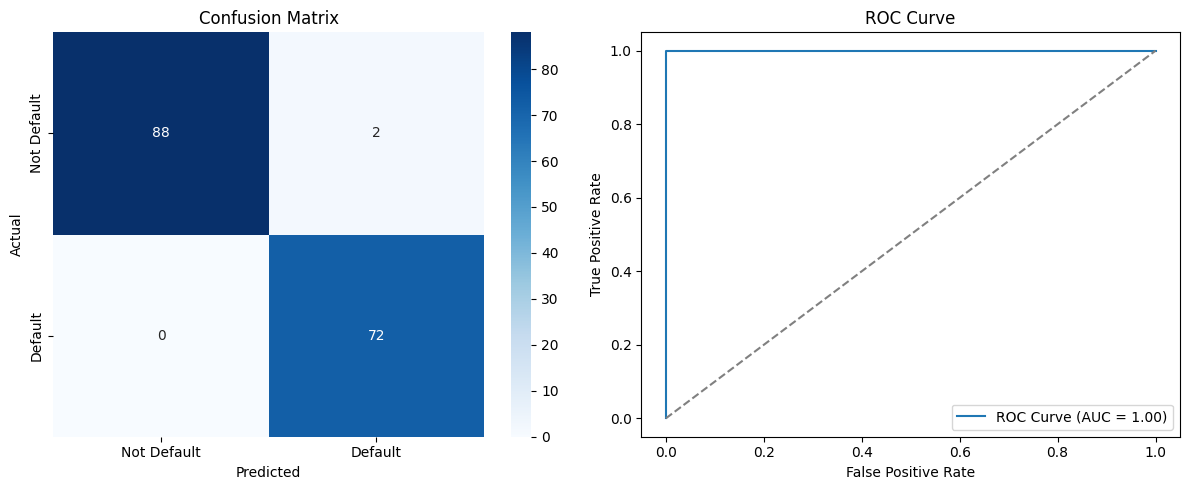

In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# ROC-AUC Score
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif (default)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Buat figure dengan 1 baris, 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Confusion Matrix (Kiri)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Plot ROC Curve (Kanan)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Tampilkan kedua plot
plt.tight_layout()
plt.show()


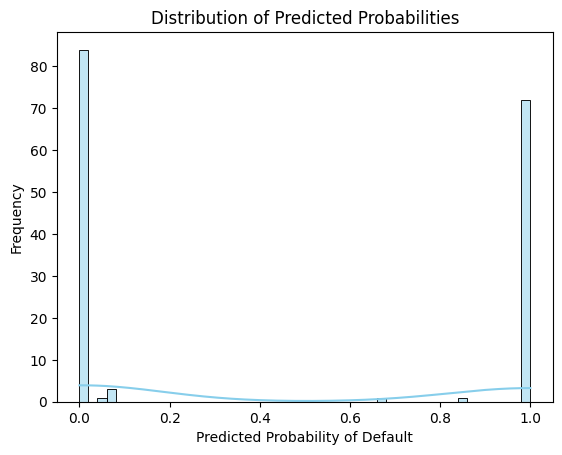

In [ ]:
# Distribusi probabilitas prediksi
sns.histplot(y_pred_proba, bins=50, kde=True, color='skyblue')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.show()

## Deposit Growth vs Loan Growth

### Merge Dataframe

In [ ]:
df_segmented_trans = df_completed_trans_eda.copy()

####Deposit Growth, regular loan growth

In [ ]:
growth_deposit_loan = trans_loan.copy()

In [ ]:
# Create a dictionary to store the latest balance for each account
latest_balance = {}

# Create a new DataFrame to store monthly balances
monthly_balances = []

# Iterate through each unique month_year in sorted order
for month_year in sorted(growth_deposit_loan['month_year'].unique()):
    # Filter transactions for the current month
    current_month_data = growth_deposit_loan[growth_deposit_loan['month_year'] == month_year]

    # Update latest balances for accounts that have transactions this month
    for index, row in current_month_data.iterrows():
        latest_balance[row['account_id']] = row['balance']

    # Sum the latest balances for all accounts
    total_balance = sum(latest_balance.values())

    # Append the result to monthly_balances
    monthly_balances.append({'month_year': month_year, 'deposit_growth': total_balance})

# Convert the results into a DataFrame
monthly_growth_df = pd.DataFrame(monthly_balances)

# Display the final DataFrame
print(monthly_growth_df)

In [ ]:
growth_deposit_loan.info()

#### LuxLoan growth

In [ ]:
# Create new dataframe 'Lux_amount' with monthly sum of 'funded_amount'
Lux_amount = df_luxury_loan_defrate.groupby('funded_month')['funded_amount'].sum().reset_index()

# Convert 'funded_month' back to Period[M]
Lux_amount['funded_month'] = Lux_amount['funded_month'].dt.to_timestamp()
Lux_amount['funded_month'] = Lux_amount['funded_month'].dt.to_period('M')

In [ ]:
# Ensure 'year_month' in monthly_amount_counts is a DataFrame or Series
monthly_amount_counts = monthly_amount_counts.reset_index()

# Merge the two DataFrames with an outer join
merged_df = pd.merge(
    monthly_growth_df,
    monthly_amount_counts,
    left_on='month_year',
    right_on='year_month',
    how='outer'
)

In [ ]:
# Ensure 'year_month' in monthly_amount_counts is a DataFrame or Series
Lux_amount = Lux_amount.reset_index()

# Merge the two DataFrames with an outer join
merged_growth = pd.merge(
    merged_df,
    Lux_amount,
    left_on='month_year',
    right_on='funded_month',
    how='outer'
)

merged_growth

In [ ]:
merged_growth.info()

In [ ]:
columns_to_drop = ['index_x', 'index_y']

merged_growth = merged_growth.drop(columns=columns_to_drop)

In [ ]:
merged_growth

#### Lux Loan Repayment

In [ ]:
luxury_loan_repayment = df_luxury_loan_eda.copy()

In [ ]:
luxury_loan_repayment.info()

# Save Cleaned Data

In [ ]:
df_loan_segmentation.to_csv("df_loan_segmentation.csv", index=False)

*Disposition yang udah di edit client id nya*

In [ ]:
df_completed_disposition.to_csv("df_completed_disposition.csv", index=False)

*Data Luxury Segmentasi, may already remove outliers, mending pake yang EDA*

In [ ]:
# Save the DataFrame to an Excel file
df_luxury_loan_segmentation.to_excel('luxury_loan_segmentation.xlsx', index=False)

*Data bersih dari Luxury Loan, minus status map*

In [ ]:
# Save the DataFrame to an Excel file
df_luxury_loan_eda.to_excel('luxury_loan_eda.xlsx', index=False)

*Data gabungan dari credit score Loan dan Non-Loan*

In [ ]:
combined_credit_score.head()

In [ ]:
# Save the DataFrame to an Excel file
combined_credit_score.to_excel('combined_credit_score.xlsx', index=False)

*Data Deposit Growth dan Loan (regular) Growth*  

In [ ]:
# Save the DataFrame to an Excel file
merged_growth.to_excel('merged_growth.xlsx', index=False)

#Another Data That Probably Needed

In [ ]:
# Read the crm_call_center_logs.csv file into a DataFrame
df_completedorder = pd.read_csv(os.path.join(path, "completedorder.csv"))

df_completedorder

## CRM events

In [ ]:
# Read the crm_events.csv file into a DataFrame
df_crm_events = pd.read_csv(os.path.join(path, "crm_events.csv"))

# Display the first few rows of the DataFrame
df_crm_events

In [ ]:
df_crm_events.isnull().sum()

In [ ]:
# Count the values
unique_data_crm_event = ['product', 'issue', 'submitted_via', 'company_response_to_consumer', 'timely_response', 'consumer_disputed']

for i in unique_data_crm_event :
    unique_data_crm_event = df_crm_events[i].value_counts()
    print(unique_data_crm_event.to_markdown(), '\n\n')

## CRM Reviews

In [ ]:
# Read the crm_reviews.csv file into a DataFrame
df_crm_reviews = pd.read_csv(os.path.join(path, "crm_reviews.csv"))

# Display the first few rows of the DataFrame
df_crm_reviews.head()

##Complete Acct

In [ ]:
# Read the completeddistrict.csv file into a DataFrame
df_completed_acct = pd.read_csv(os.path.join(path, "completedacct.csv"))

# Display the first few rows of the DataFrame
df_completed_acct

In [ ]:
df_completed_acct.info()

In [ ]:
# Convert 'parseddate' and 'date' to datetime format
df_completed_acct['parseddate'] = pd.to_datetime(df_completed_acct['parseddate'])
df_completed_acct['date'] = pd.to_datetime(df_completed_acct['date'])
df_completed_acct['district_id'] = df_completed_acct['district_id'].astype(str)

In [ ]:
for column_name in df_completed_acct.columns:
    print(df_completed_acct[column_name].value_counts(), "\n")

In [ ]:
df_completed_acct.isnull().sum()

In [ ]:
df_account_district_debug = df_completed_acct.merge(df_completed_district, on='district_id', how='left', indicator=True)
print(df_account_district_debug['_merge'].value_counts())

In [ ]:
df_account_district_debug

In [ ]:
# Pastikan kolom 'parseddate' dalam format datetime
df_completed_acct['parseddate'] = pd.to_datetime(df_completed_acct['parseddate'])

# Buat kolom 'year' dari 'parseddate'
df_completed_acct['year'] = df_completed_acct['parseddate'].dt.year

# Agregasi data: Hitung jumlah akun per tahun berdasarkan frekuensi issuance
freq_per_year = df_completed_acct.groupby(['year', 'frequency']).size().unstack(fill_value=0)

# Visualisasi data
freq_per_year.plot(kind='bar', figsize=(10, 6))
plt.title('Perbandingan Frekuensi Issuance per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Akun')
plt.legend(title='Frekuensi Issuance')
plt.xticks(rotation=0)
plt.show()